In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.special import inv_boxcox
import warnings
import numpy as np


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)

In [188]:
df = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/base_train.csv')

In [51]:
df_val = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/base_val.csv')

# Base Train

### Conocimiento Base

El df tiene 26266 filas y 24 columnas

In [189]:
df.shape

(26266, 24)

Informacion:

In [190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26266 entries, 0 to 26265
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                26266 non-null  int64  
 1   track_id                  26266 non-null  object 
 2   track_name                26261 non-null  object 
 3   track_artist              26261 non-null  object 
 4   track_popularity          26266 non-null  int64  
 5   track_album_id            26266 non-null  object 
 6   track_album_name          26261 non-null  object 
 7   track_album_release_date  26266 non-null  object 
 8   playlist_name             26266 non-null  object 
 9   playlist_id               26266 non-null  object 
 10  playlist_genre            26266 non-null  object 
 11  playlist_subgenre         26266 non-null  object 
 12  danceability              26266 non-null  float64
 13  energy                    26266 non-null  float64
 14  key   

Vemos nulos --> track_name, track_artist y track_album_name contienen nulos --> no las vamos a usar

In [191]:
df.isna().sum()

,0
Unnamed: 0,0
track_id,0
track_name,5
track_artist,5
track_popularity,0
track_album_id,0
track_album_name,5
track_album_release_date,0
playlist_name,0
playlist_id,0


Las examinamos:

In [192]:
print(f'La variable id tiene el {(df['Unnamed: 0'].nunique() / df.shape[0])*100} de los valores siendo distintos')
print(f'La variable id tiene el {(df['track_id'].nunique() / df.shape[0])*100} de los valores siendo distintos')

La variable id tiene el 100.0 de los valores siendo distintos
La variable id tiene el 87.54663823954922 de los valores siendo distintos


In [193]:
print('Valores unicos de:')
print(f'track_id: {df["track_id"].nunique()}')
print(f'track_name: {df["track_name"].nunique()}')
print(f'track_artist: {df["track_artist"].nunique()}')
print(f'track_album_id: {df["track_album_id"].nunique()}')
print(f'track_album_name: {df["track_album_name"].nunique()}')
print(f'playlist_id: {df["playlist_id"].nunique()}')
print(f'playlist_name: {df["playlist_name"].nunique()}')

Valores unicos de:
track_id: 22995
track_name: 19269
track_artist: 8786
track_album_id: 17816
track_album_name: 15961
playlist_id: 390
playlist_name: 368


In [194]:
proporcion_playlists = df['playlist_name'].value_counts()
proporcion_playlists[proporcion_playlists > 50]

,count
playlist_name,
a5/abzKkVku2Puxrfq9FaVA3EHHlPgU9yRqhtwQiga4=,308
NhpNmsibBnouShJ9E5i/DsUXP0abfbQVecUrjKOx4AAFeWElOkcaCZHQK1n61jsfXHmLWOyzfd47xkSqdz/u9rTIYuTNSu9Ju/OUnspk004=,247
Fx9XY61BGoLNgOafj97pi3tVbg52457FB+1jEfLN94o=,244
KeSBp4W+y0QF31qblu+X29ZbOlBTNW556R6P6otZ6yQEYSRxFrrWlFu06HJIa9ke,219
x/XAnugy+wgiIhBscwIbkLArzpDqobu3CZ/QlwZznf+1/TAnIczQ9II0LbU8ynEyfXhQuemyO6qjsbywCNE+vVWWKZCH9uokoh3Rwp8y3xc=,198
...,...
pK4PB/QNksFYnFKMmpexcGGZGoGVzReb9NPSsJxe1sA=,53
E6QFSnm+uIYYxzTt0PLi61/ORBTza2YrCtv0B3+7Uk8j1a+IEYH+F6YqmRCp4wJE,53
Kj7HSeXQNpMvsyszw+5wOMyY8BimPmYCxOenGhzKJfY=,53


### Conversion Fecha

- Las fechas tienen 0, 1 o 2 '-' --> o sea que estan solo con el año, año y con mes o con año, mes y dia

- Todas las fechas están dentro de alguna de esas 3 combinaciones

In [195]:
serie = pd.DataFrame(df['track_album_release_date'])
serie['cantidad_-'] = df['track_album_release_date'].apply(lambda x: x.count('-'))
serie['fecha_con_-'] = df['track_album_release_date'].apply(lambda x: x.split('-'))
serie['longitud'] = serie['fecha_con_-'].apply(lambda x: len(x))

In [196]:
serie[serie['cantidad_-'] == 0]['track_album_release_date'].unique()

array(['2012', '1998', '1996', '1999', '1993', '1991', '2000', '1994',
       '2007', '1995', '2003', '2019', '2011', '2010', '2008', '2014',
       '2009', '2013', '1988', '2005', '2004', '1973', '1977', '1981',
       '1970', '1976', '1987', '1980', '1984', '1985', '2002', '2001',
       '2016', '1978', '1982', '2006', '1997', '1983', '1986', '1979',
       '1989', '1990', '1975', '2015', '2017', '1968', '1972', '1969',
       '1974', '1992', '1971', '1967', '1965', '1962', '1960', '1966',
       '1964', '1963'], dtype=object)

In [197]:
serie[serie['cantidad_-'] == 1]['track_album_release_date'].unique()

array(['1981-12', '1981-03', '1967-09', '1966-02', '1971-03', '1978-04',
       '1976-12', '1973-09', '1977-09', '1978-01', '1977-02', '1978-09',
       '1967-04', '1957-03', '1966-09', '1970-02', '1978-08', '1971-07',
       '1973-05'], dtype=object)

In [198]:
serie[serie['cantidad_-'] == 2]['track_album_release_date'].unique()

array(['2019-06-14', '2019-12-13', '2019-07-05', ..., '2016-07-06',
       '2008-01-21', '2014-07-18'], dtype=object)

In [199]:
(serie[serie['cantidad_-'] == 0].shape[0] + serie[serie['cantidad_-'] == 1].shape[0] + serie[serie['cantidad_-'] == 2].shape[0]) == df.shape[0]

True

Transformamos

In [200]:
df['anio'] = df['track_album_release_date'].apply(lambda x: x.split('-')[0])
df['anio'] = df['anio'].astype(int)

<Axes: ylabel='Frequency'>

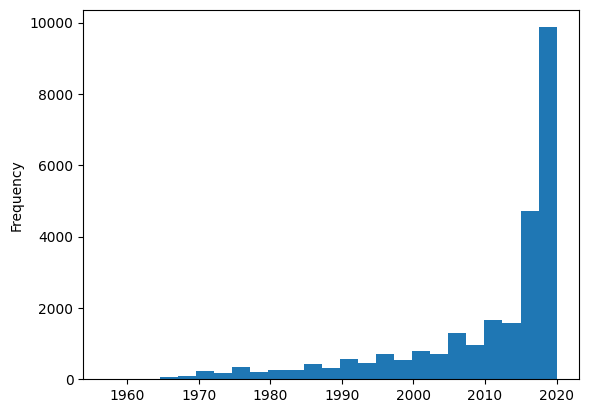

In [201]:
df['anio'].plot(kind='hist', bins=25)

In [202]:
def imputacion_anio(anio: int):
  if anio < 1980:
    return 1970
  if anio < 1990:
    return 1980
  if anio < 2000:
    return 1990
  if anio < 2010:
    return 2000
  if anio < 2015:
    return 2010
  return anio

In [203]:
df['grupo_anio'] = df['anio'].apply(imputacion_anio)

### Outliers numericas

In [204]:
numericas = ['danceability', 'energy',
       'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms']

In [205]:
def primer_paso_outliers(df, lista_columnas: list[str]):
  '''
  Debe hacerse para columnas numericas
  '''
  for col in lista_columnas:
    # Chequeo de normalidad -> ya que es muy comun en outliers para despues transformar o no los datos
    print(f'Variable {col} tiene un p-valor de normalidad de {stats.normaltest(df[col].dropna()).pvalue}')

    # Visualizamos esa variable
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribución de {col}")
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [206]:
def outliers_IQR(df, columna, severos=False):
    '''
    Debe hacerse solo para columnas numericas
    '''
    q_IQR = 3 if severos else 1.5
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - q_IQR * IQR
    limite_superior = Q3 + q_IQR * IQR
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    mask_outliers = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    return outliers, mask_outliers

In [207]:
def detectar_outliers_IQR(df, lista_columnas: list[str], p_valor_threshold=0.05, severos=False, imputo=False):
    '''
    Debe hacerse solo para columnas numericas
    '''
    df_copia = df.copy()
    masks_orig = dict()
    masks_transf = dict()
    for col in lista_columnas:
        mask = df_copia[col].notna()
        # Probamos si la columna sigue una distribucion normal
        print(f'Columna: {col}')
        p_valor = stats.shapiro(df_copia.loc[mask,col]).pvalue          # si la muestra es muy grande, usar stats.normaltest()
        print(f'P-valor de la prueba de normalidad de Shapiro-Wilk: {p_valor}. {"" if p_valor > p_valor_threshold else "No "}se puede asumir normalidad.')

        # Contamos los outliers en la distribucion original
        outliers_orig, mask_outliers_orig = outliers_IQR(df_copia, col, severos=severos)
        q_outliers_original = outliers_orig.shape[0]
        print(f'Numero de outliers IQR detectados en la distribucion original: {q_outliers_original}')

        if p_valor > p_valor_threshold:
            mask_outliers_transf = None
            # Imputo si corresponde
            if imputo:
                mediana = df_copia.loc[~mask_outliers_orig, col].median()
                df_copia.loc[mask_outliers_orig == True, col] = mediana

        # Si la columna no sigue una distribución normal, aplicamos una transformacion
        else:
            minimo = df_copia[col].min()
            if minimo > 0:
                metodo = 'boxcox'
                data_bc, lambda_bc = stats.boxcox(df_copia.loc[mask, col])
                df_copia.loc[mask, metodo + '_' + col] = data_bc
            else:
                metodo = 'yeojohnson'
                data_yeo, lambda_yeo = stats.yeojohnson(df_copia.loc[mask, col])
                df_copia.loc[mask, metodo + '_' + col] = data_yeo
            outliers_transf, mask_outliers_transf = outliers_IQR(df_copia, metodo + '_' + col, severos=severos)
            q_outliers_transf = outliers_transf.shape[0]
            print(f'Metodo de transformacion aplicado: {metodo}')
            print(f'Numero de outliers IQR detectados en la distribucion transformada: {q_outliers_transf}')

            # Imputo si corresponde
            if imputo:
                mediana = df_copia.loc[~mask_outliers_transf, col].median()
                df_copia.loc[mask_outliers_transf == True, col] = mediana
        masks_orig[col] = mask_outliers_orig
        masks_transf[col] = mask_outliers_transf

    df_copia = df_copia.loc[:,lista_columnas]
    return df_copia, masks_orig, masks_transf

Cantidad de variables numericas a analizar en este apartado: 10

In [208]:
len(numericas)

10

Variable danceability tiene un p-valor de normalidad de 5.7595017109342064e-242


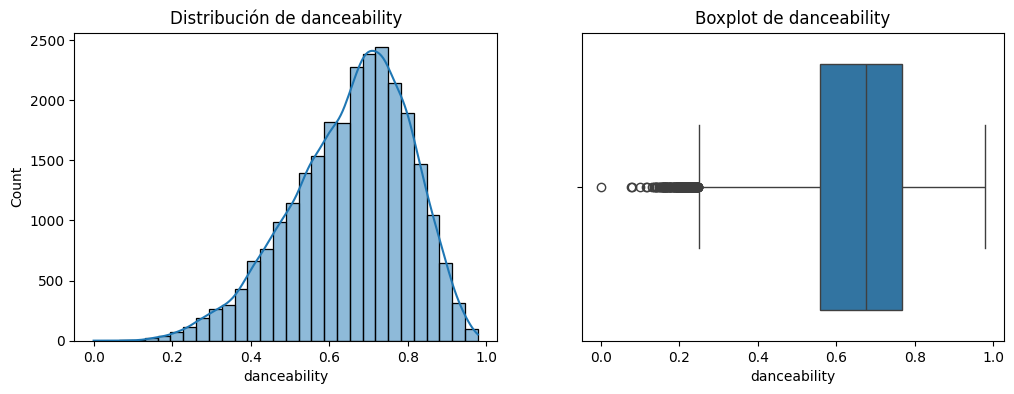

Variable energy tiene un p-valor de normalidad de 1.2707282780466982e-267


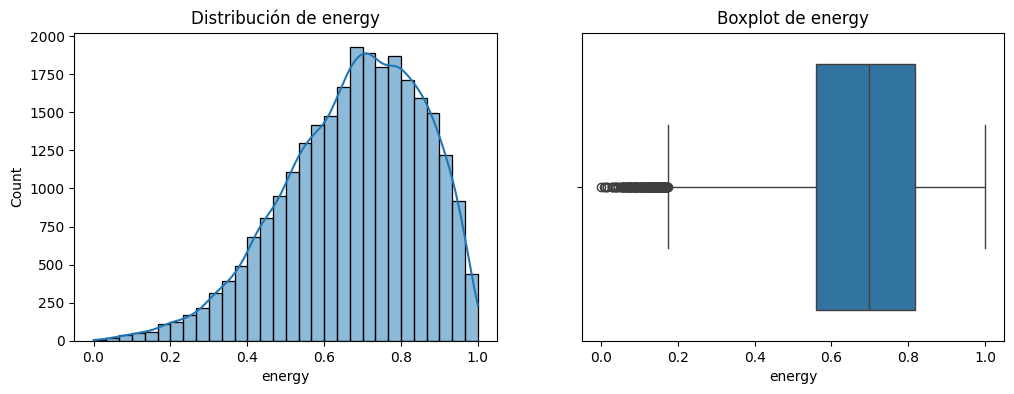

Variable loudness tiene un p-valor de normalidad de 0.0


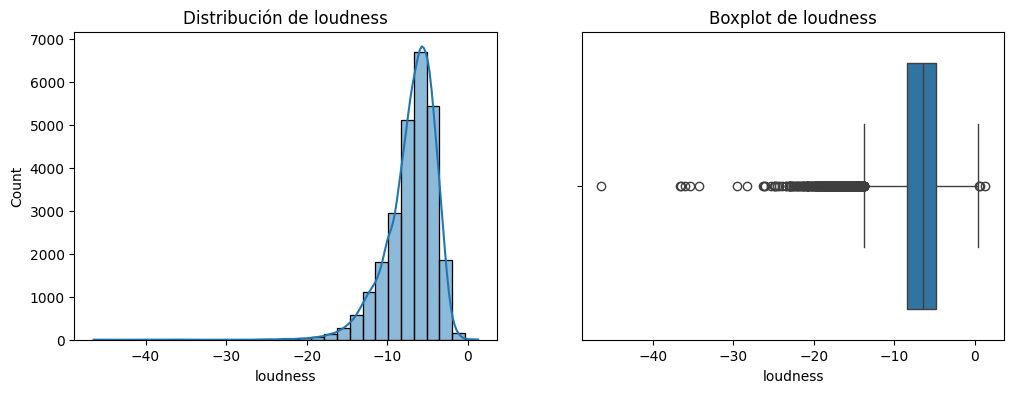

Variable speechiness tiene un p-valor de normalidad de 0.0


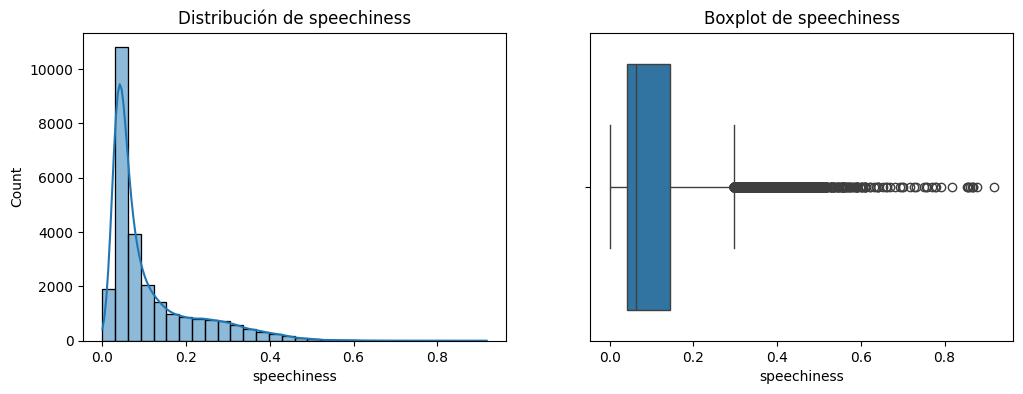

Variable acousticness tiene un p-valor de normalidad de 0.0


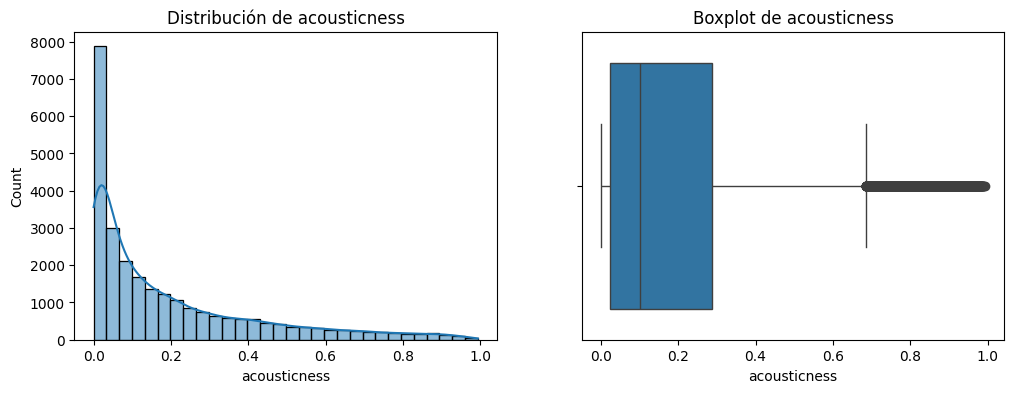

Variable instrumentalness tiene un p-valor de normalidad de 0.0


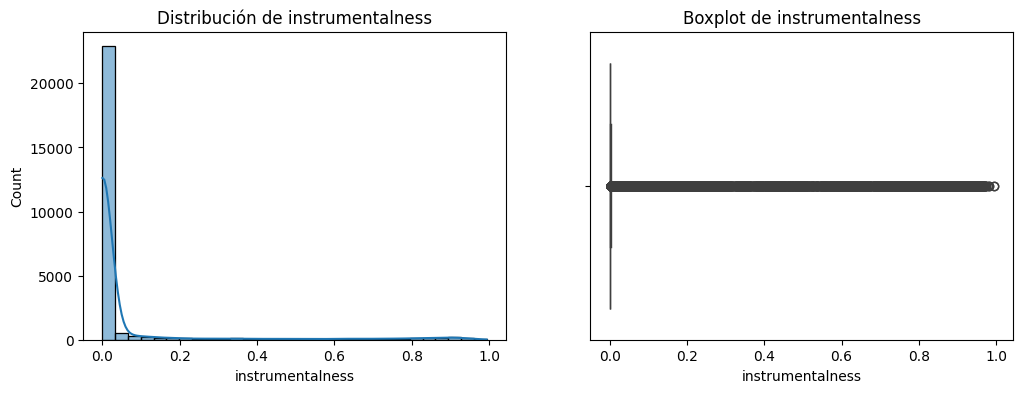

Variable liveness tiene un p-valor de normalidad de 0.0


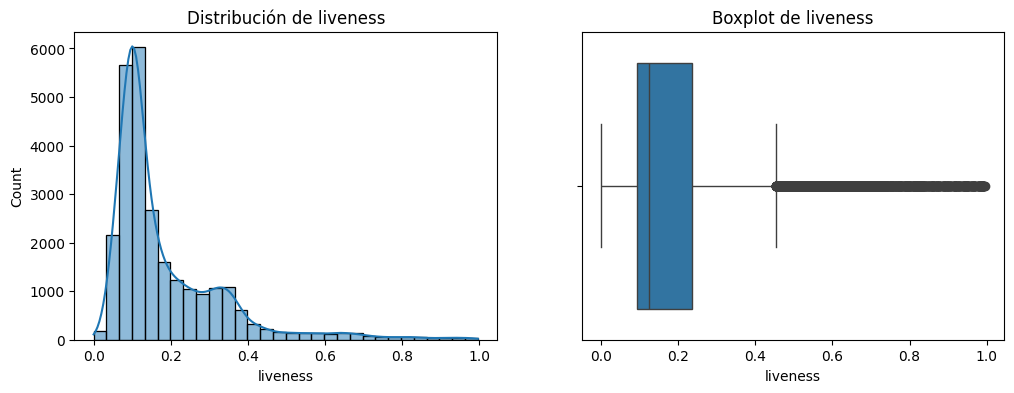

Variable valence tiene un p-valor de normalidad de 0.0


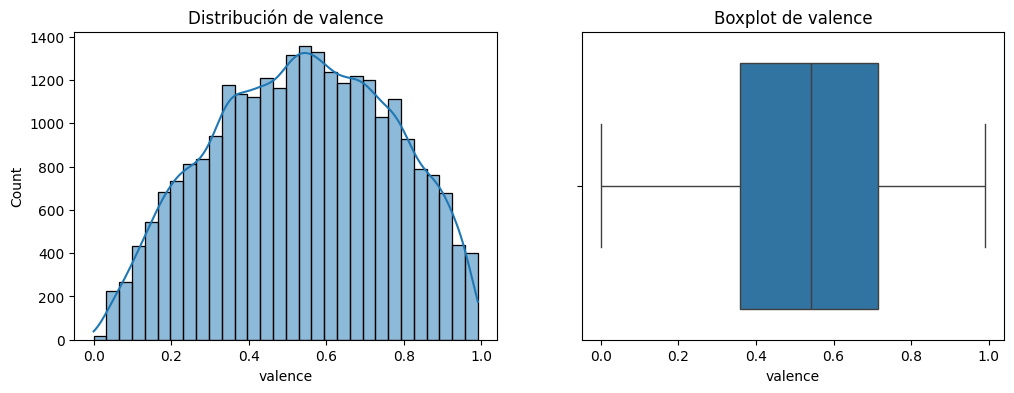

Variable tempo tiene un p-valor de normalidad de 1.4778798456587946e-298


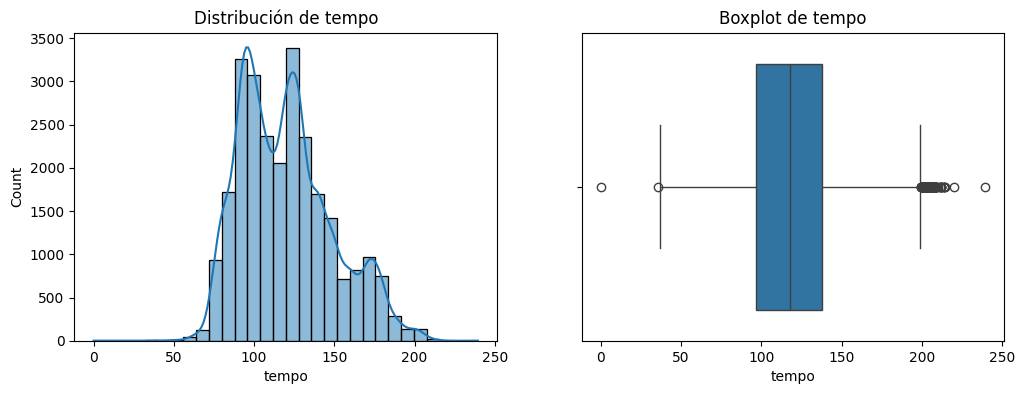

Variable duration_ms tiene un p-valor de normalidad de 0.0


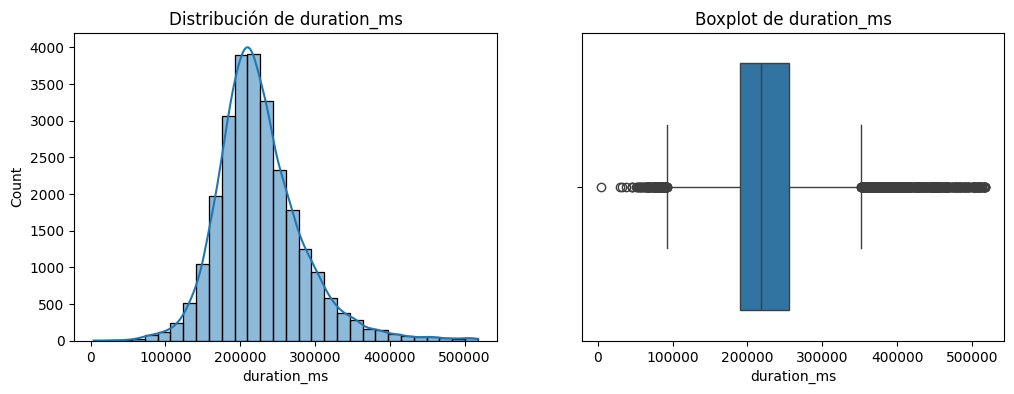

In [209]:
primer_paso_outliers(df, numericas)

**Comentarios**: *Ninguna distribución dio normalidad via test formal*

- Danceability: asimetria a izquierda
- Energy: asimetria a izquierda
- Loudness: asimetria a izquierda, valores menores a -20 son preocupantes si vemos el histograma
- Speechiness: la mayoria estan entre 0.1 y 0.2. Mayores a 0.45 diria de corregir
- Acousticness: lognormal perfecta diria pero parece que está bien, los outliers tienen sentido y son muy graduales
- Instrumentalness: cuidado! valores mayores a 0.1 o parecido son muy muy pocos chequear
- Liveness: podriamos agrupar mayores a 0.5 en ese valor, ya que son pocos en relacion a las frecuencias cercanas a 0.5
- Valence: parece bastantante normal, pero bien robusta, y no tiene outliers
- Tempo: da sensacion de bimodal
- Duration_ms: una normal hermosa, con outliers sobretodo en la parte derecha de la distribucion

In [210]:
outliers = detectar_outliers_IQR(df, numericas)

Columna: danceability
P-valor de la prueba de normalidad de Shapiro-Wilk: 3.1006691123459554e-51. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 199
Metodo de transformacion aplicado: yeojohnson
Numero de outliers IQR detectados en la distribucion transformada: 1
Columna: energy
P-valor de la prueba de normalidad de Shapiro-Wilk: 1.6539121998252907e-55. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 194
Metodo de transformacion aplicado: boxcox
Numero de outliers IQR detectados en la distribucion transformada: 0
Columna: loudness
P-valor de la prueba de normalidad de Shapiro-Wilk: 1.036388753178707e-76. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 796
Metodo de transformacion aplicado: yeojohnson
Numero de outliers IQR detectados en la distribucion transformada: 275
Columna: speechiness
P-valor de la prueba de normalidad de Shapiro-Wilk: 1.59883

Variables con outliers en la distribución transformada:
- Danceability: 1
- Loudness: 275
- Instrumentalness: 5582
- Tempo: 15
- Duration ms: 827

Vars sin outliers fueron 5

In [211]:
outliers_severos = detectar_outliers_IQR(df, numericas, severos=True)

Columna: danceability
P-valor de la prueba de normalidad de Shapiro-Wilk: 3.1006691123459554e-51. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 0
Metodo de transformacion aplicado: yeojohnson
Numero de outliers IQR detectados en la distribucion transformada: 0
Columna: energy
P-valor de la prueba de normalidad de Shapiro-Wilk: 1.6539121998252907e-55. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 0
Metodo de transformacion aplicado: boxcox
Numero de outliers IQR detectados en la distribucion transformada: 0
Columna: loudness
P-valor de la prueba de normalidad de Shapiro-Wilk: 1.036388753178707e-76. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 85
Metodo de transformacion aplicado: yeojohnson
Numero de outliers IQR detectados en la distribucion transformada: 13
Columna: speechiness
P-valor de la prueba de normalidad de Shapiro-Wilk: 1.59883553173

Outliers **severos** en la distribución transformada:

- Loudness: 13
- Instrumentalness: 5048
- Tempo: 1
- Duration ms: 23

Vars sin outliers **severos** en la distribución transformada: 6

### Correcion Outliers

Corregimos outliers normales en la distribución transformada

In [212]:
def outliers_IQR_bis(df, columna, severos=False):
    '''
    Debe hacerse solo para columnas numericas
    '''
    q_IQR = 3 if severos else 1.5
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - q_IQR * IQR
    limite_superior = Q3 + q_IQR * IQR
    outliers_inf = df[(df[columna] < limite_inferior)]
    mask_outliers_inf = (df[columna] < limite_inferior)
    outliers_sup = df[(df[columna] > limite_superior)]
    mask_outliers_sup = (df[columna] > limite_superior)
    return outliers_inf, mask_outliers_inf, outliers_sup, mask_outliers_sup, limite_inferior, limite_superior

In [213]:
def inverse_yeojohnson(x, lmbda):
    x = np.asarray(x)
    out = np.zeros_like(x)
    # Caso x >= 0
    pos = x >= 0
    if lmbda == 0:
        out[pos] = np.exp(x[pos]) - 1
    else:
        out[pos] = np.power(x[pos] * lmbda + 1, 1 / lmbda) - 1
    # Caso x < 0
    neg = ~pos
    if lmbda == 2:
        out[neg] = 1 - np.exp(-x[neg])
    else:
        out[neg] = 1 - np.power(-(2 - lmbda) * x[neg] + 1,
                                1 / (2 - lmbda))
    return out

#### Danceability

Es un solo outlier, que es 0. Lo reemplazamos por el valor mínimo distinto de 0

In [214]:
var_a_corregir = 'danceability'
metodo = 'YeoJohnson'

data_bc, lambda_bc = stats.yeojohnson(df[var_a_corregir])
df_var = pd.DataFrame(data_bc, columns=[var_a_corregir])
outliers_inf, mask_outliers_inf, outliers_sup, mask_outliers_sup, limite_inferior, limite_superior = outliers_IQR_bis(df_var, var_a_corregir, severos=False)

print(f'Metodo de transformacion aplicado: {metodo}')
print(f'Numero de outliers IQR inferiores detectados en la distribucion transformada: {outliers_inf.shape[0]}')
print(f'Numero de outliers IQR superiores detectados en la distribucion transformada: {outliers_sup.shape[0]}')

Metodo de transformacion aplicado: YeoJohnson
Numero de outliers IQR inferiores detectados en la distribucion transformada: 1
Numero de outliers IQR superiores detectados en la distribucion transformada: 0


<Axes: xlabel='danceability', ylabel='Count'>

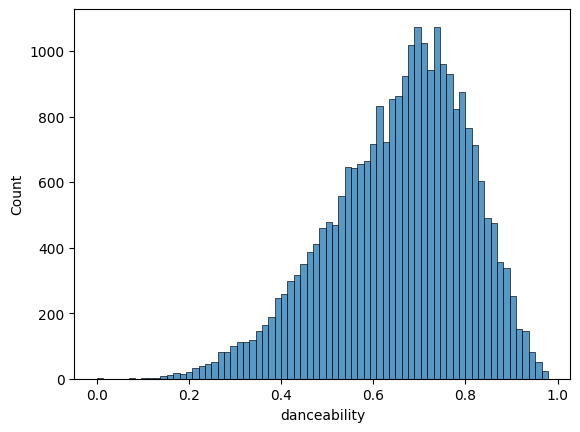

In [215]:
sns.histplot(data=df[var_a_corregir])

<Axes: >

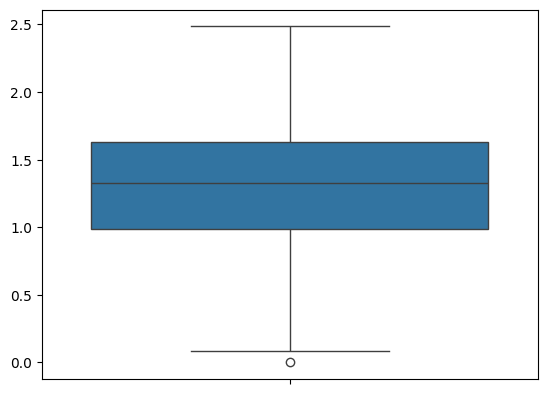

In [216]:
sns.boxplot(data_bc)

In [217]:
limite_inferior

np.float64(0.025735177250712837)

In [218]:
y_original = inverse_yeojohnson(limite_inferior, lambda_bc)
df.loc[mask_outliers_inf, 'danceability'] = y_original

<Axes: xlabel='danceability', ylabel='Count'>

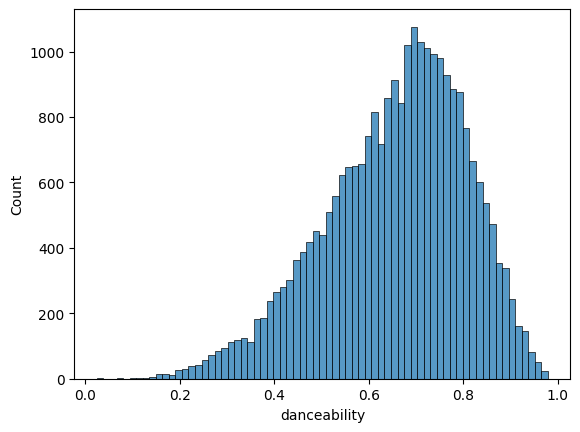

In [219]:
sns.histplot(data=df[var_a_corregir])

#### Loudness

Reemplazamos los valores inferiores a percentil 25  - 1,5*IQR por el limite inferior y lo mismo con los valores superiores al limite superior

In [220]:
var_a_corregir = 'loudness'
metodo = 'YeoJohnson'

data_bc, lambda_bc = stats.yeojohnson(df[var_a_corregir])
df_var = pd.DataFrame(data_bc, columns=[var_a_corregir])
outliers_inf, mask_outliers_inf, outliers_sup, mask_outliers_sup, limite_inferior, limite_superior = outliers_IQR_bis(df_var, var_a_corregir, severos=False)

print(f'Metodo de transformacion aplicado: {metodo}')
print(f'Numero de outliers IQR inferiores detectados en la distribucion transformada: {outliers_inf.shape[0]}')
print(f'Numero de outliers IQR superiores detectados en la distribucion transformada: {outliers_sup.shape[0]}')

Metodo de transformacion aplicado: YeoJohnson
Numero de outliers IQR inferiores detectados en la distribucion transformada: 143
Numero de outliers IQR superiores detectados en la distribucion transformada: 132


<Axes: xlabel='loudness', ylabel='Count'>

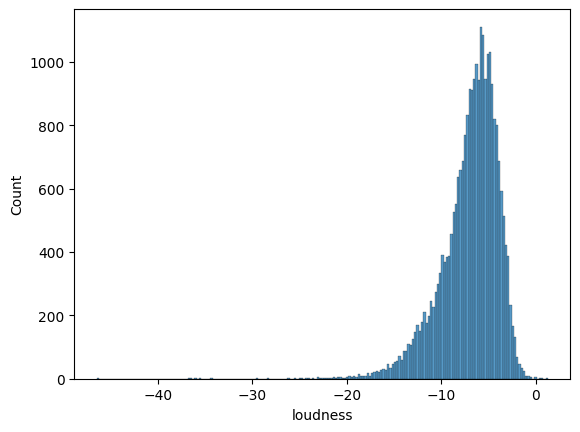

In [221]:
sns.histplot(data=df[var_a_corregir])

<Axes: >

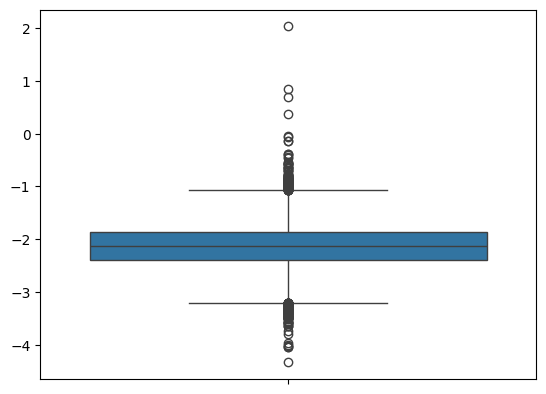

In [222]:
sns.boxplot(data_bc)

In [223]:
y_inferior = inverse_yeojohnson(limite_inferior, lambda_bc)
df.loc[mask_outliers_inf, var_a_corregir] = y_inferior

y_superior = inverse_yeojohnson(limite_superior, lambda_bc)
df.loc[mask_outliers_sup, var_a_corregir] = y_superior

<Axes: xlabel='loudness', ylabel='Count'>

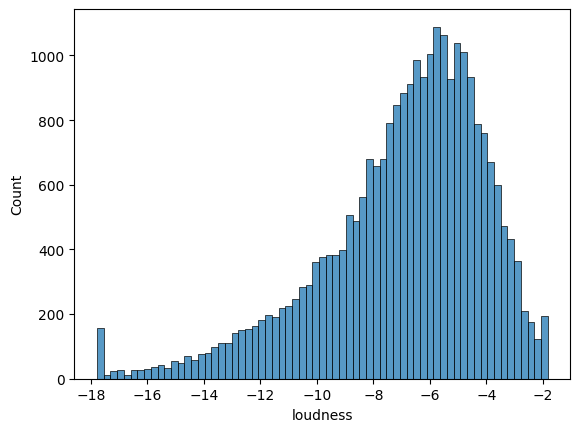

In [224]:
sns.histplot(data=df[var_a_corregir])

#### Tempo

Corregimos los outlier inferiores como el limite inferior de percentil 25-1,5*IQR y lo mismo con el outlier superior

In [225]:
df['tempo'].min()

0.0

In [226]:
var_a_corregir = 'tempo'
metodo = 'YeoJohnson'

data_bc, lambda_bc = stats.yeojohnson(df[var_a_corregir])
df_var = pd.DataFrame(data_bc, columns=[var_a_corregir])
outliers_inf, mask_outliers_inf, outliers_sup, mask_outliers_sup, limite_inferior, limite_superior = outliers_IQR_bis(df_var, var_a_corregir, severos=False)

print(f'Metodo de transformacion aplicado: {metodo}')
print(f'Numero de outliers IQR inferiores detectados en la distribucion transformada: {outliers_inf.shape[0]}')
print(f'Numero de outliers IQR superiores detectados en la distribucion transformada: {outliers_sup.shape[0]}')

Metodo de transformacion aplicado: YeoJohnson
Numero de outliers IQR inferiores detectados en la distribucion transformada: 14
Numero de outliers IQR superiores detectados en la distribucion transformada: 1


<Axes: xlabel='tempo', ylabel='Count'>

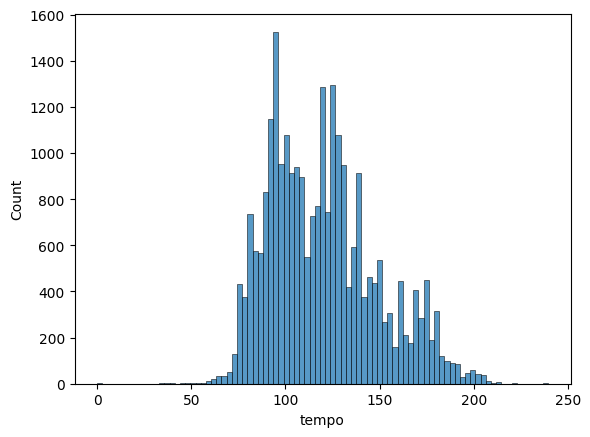

In [227]:
sns.histplot(data=df[var_a_corregir])

<Axes: >

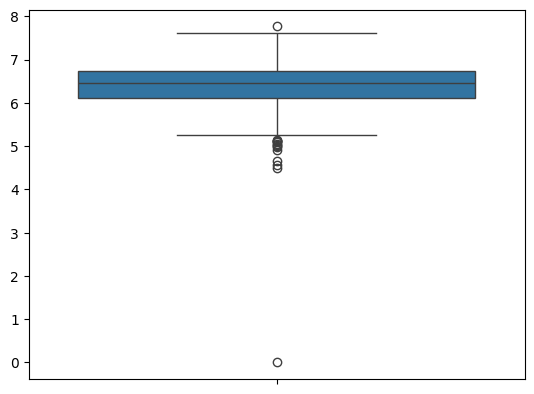

In [228]:
sns.boxplot(data_bc)

In [229]:
y_inferior = inverse_yeojohnson(limite_inferior, lambda_bc)
df.loc[mask_outliers_inf, var_a_corregir] = y_inferior

y_superior = inverse_yeojohnson(limite_superior, lambda_bc)
df.loc[mask_outliers_sup, var_a_corregir] = y_superior

In [230]:
y_inferior, y_superior

(array(55.28928946), array(227.38184983))

<Axes: xlabel='tempo', ylabel='Count'>

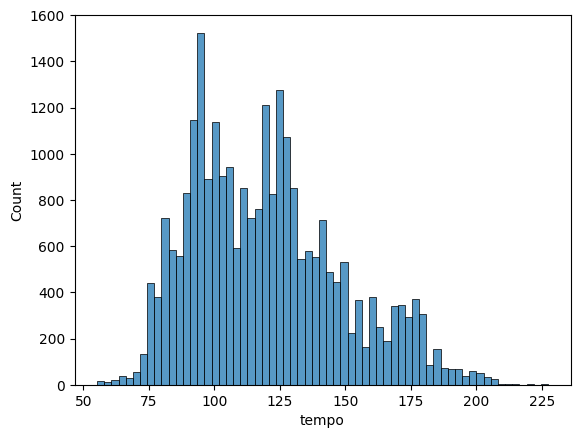

In [231]:
sns.histplot(data=df[var_a_corregir])

#### Duration_ms

In [232]:
var_a_corregir = 'duration_ms'
metodo = 'boxcox'

data_bc, lambda_bc = stats.boxcox(df[var_a_corregir])
df_var = pd.DataFrame(data_bc, columns=[var_a_corregir])
outliers_inf, mask_outliers_inf, outliers_sup, mask_outliers_sup, limite_inferior, limite_superior = outliers_IQR_bis(df_var, var_a_corregir, severos=False)

print(f'Metodo de transformacion aplicado: {metodo}')
print(f'Numero de outliers IQR inferiores detectados en la distribucion transformada: {outliers_inf.shape[0]}')
print(f'Numero de outliers IQR superiores detectados en la distribucion transformada: {outliers_sup.shape[0]}')

Metodo de transformacion aplicado: boxcox
Numero de outliers IQR inferiores detectados en la distribucion transformada: 351
Numero de outliers IQR superiores detectados en la distribucion transformada: 476


<Axes: xlabel='duration_ms', ylabel='Count'>

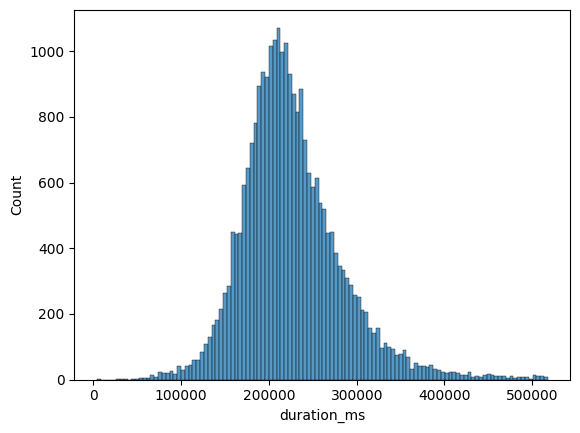

In [233]:
sns.histplot(data=df[var_a_corregir])

<Axes: >

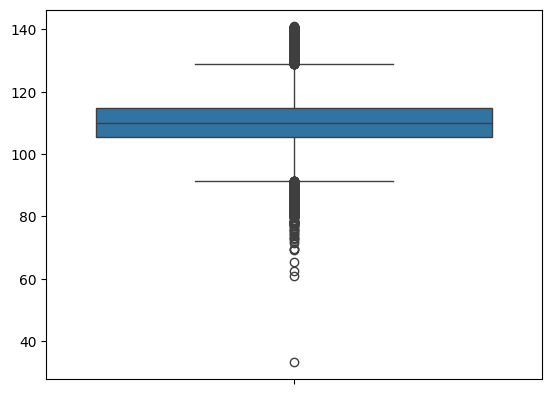

In [234]:
sns.boxplot(data_bc)

In [235]:
y_inferior = inv_boxcox(limite_inferior, lambda_bc)
df.loc[mask_outliers_inf, var_a_corregir] = y_inferior

y_superior = inv_boxcox(limite_superior, lambda_bc)
df.loc[mask_outliers_sup, var_a_corregir] = y_superior

<Axes: xlabel='duration_ms', ylabel='Count'>

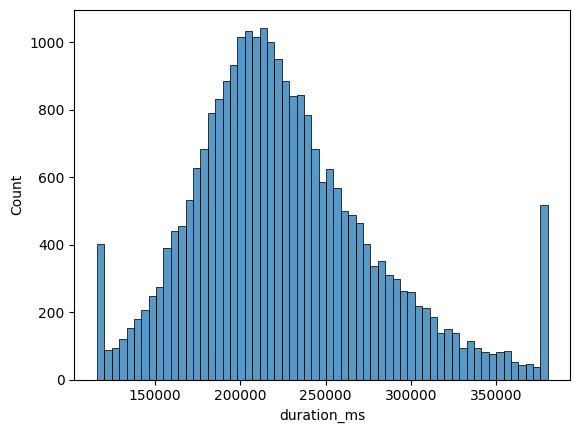

In [236]:
sns.histplot(df['duration_ms'])

#### Instrumentalness

In [237]:
df['instrumentalness'].describe()

,instrumentalness
count,26266.000000
mean,0.054880
std,0.181430
min,0.000000
25%,0.000000
50%,0.000006
75%,0.001250
max,0.994000


In [238]:
(df['instrumentalness'] > 0.001).sum()

np.int64(6857)

## Categoricas

In [239]:
df.select_dtypes(include='object').columns

Index(['track_id', 'track_name', 'track_artist', 'track_album_id',
       'track_album_name', 'track_album_release_date', 'playlist_name',
       'playlist_id', 'playlist_genre', 'playlist_subgenre'],
      dtype='object')

### Playlist_genre

In [240]:
df['playlist_genre'].value_counts()

,count
playlist_genre,
rap,5746
pop,5507
latin,5155
rock,4951
r&b,4907


In [241]:
df.groupby(['playlist_genre'])['track_popularity'].describe()

,count,mean,std,min,25%,50%,75%,max
playlist_genre,,,,,,,,
latin,5155.0,47.026576,25.424557,0.0,32.0,50.0,67.0,100.0
pop,5507.0,47.744870,25.158331,0.0,31.0,52.0,68.0,100.0
r&b,4907.0,42.736703,25.800616,0.0,23.0,46.0,63.0,99.0
rap,5746.0,43.215454,23.302085,0.0,30.0,47.0,60.0,98.0
rock,4951.0,41.728338,24.825230,0.0,21.0,46.0,63.0,95.0


In [242]:
# ANOVA
df_latin = df.loc[df['playlist_genre'] == 'latin','track_popularity']
df_pop = df.loc[df['playlist_genre'] == 'pop','track_popularity']
df_rb = df.loc[df['playlist_genre'] == 'r&b','track_popularity']
df_rap = df.loc[df['playlist_genre'] == 'rap','track_popularity']
df_rock = df.loc[df['playlist_genre'] == 'rock','track_popularity']

ANOVA=stats.f_oneway(df_latin, df_pop, df_rb, df_rap, df_rock)
print("pValor ANOVA: "+str(ANOVA.pvalue))

# Kruskal -> H0: las medianas son todas iguales
kw=stats.kruskal(df_latin, df_pop, df_rb, df_rap, df_rock)
print("pValor Kruskal Wallis: "+str(kw.pvalue))

pValor ANOVA: 2.802601299858534e-52
pValor Kruskal Wallis: 6.757706137586249e-54


Comparamos distribuciones de las variables entre playlist_genre

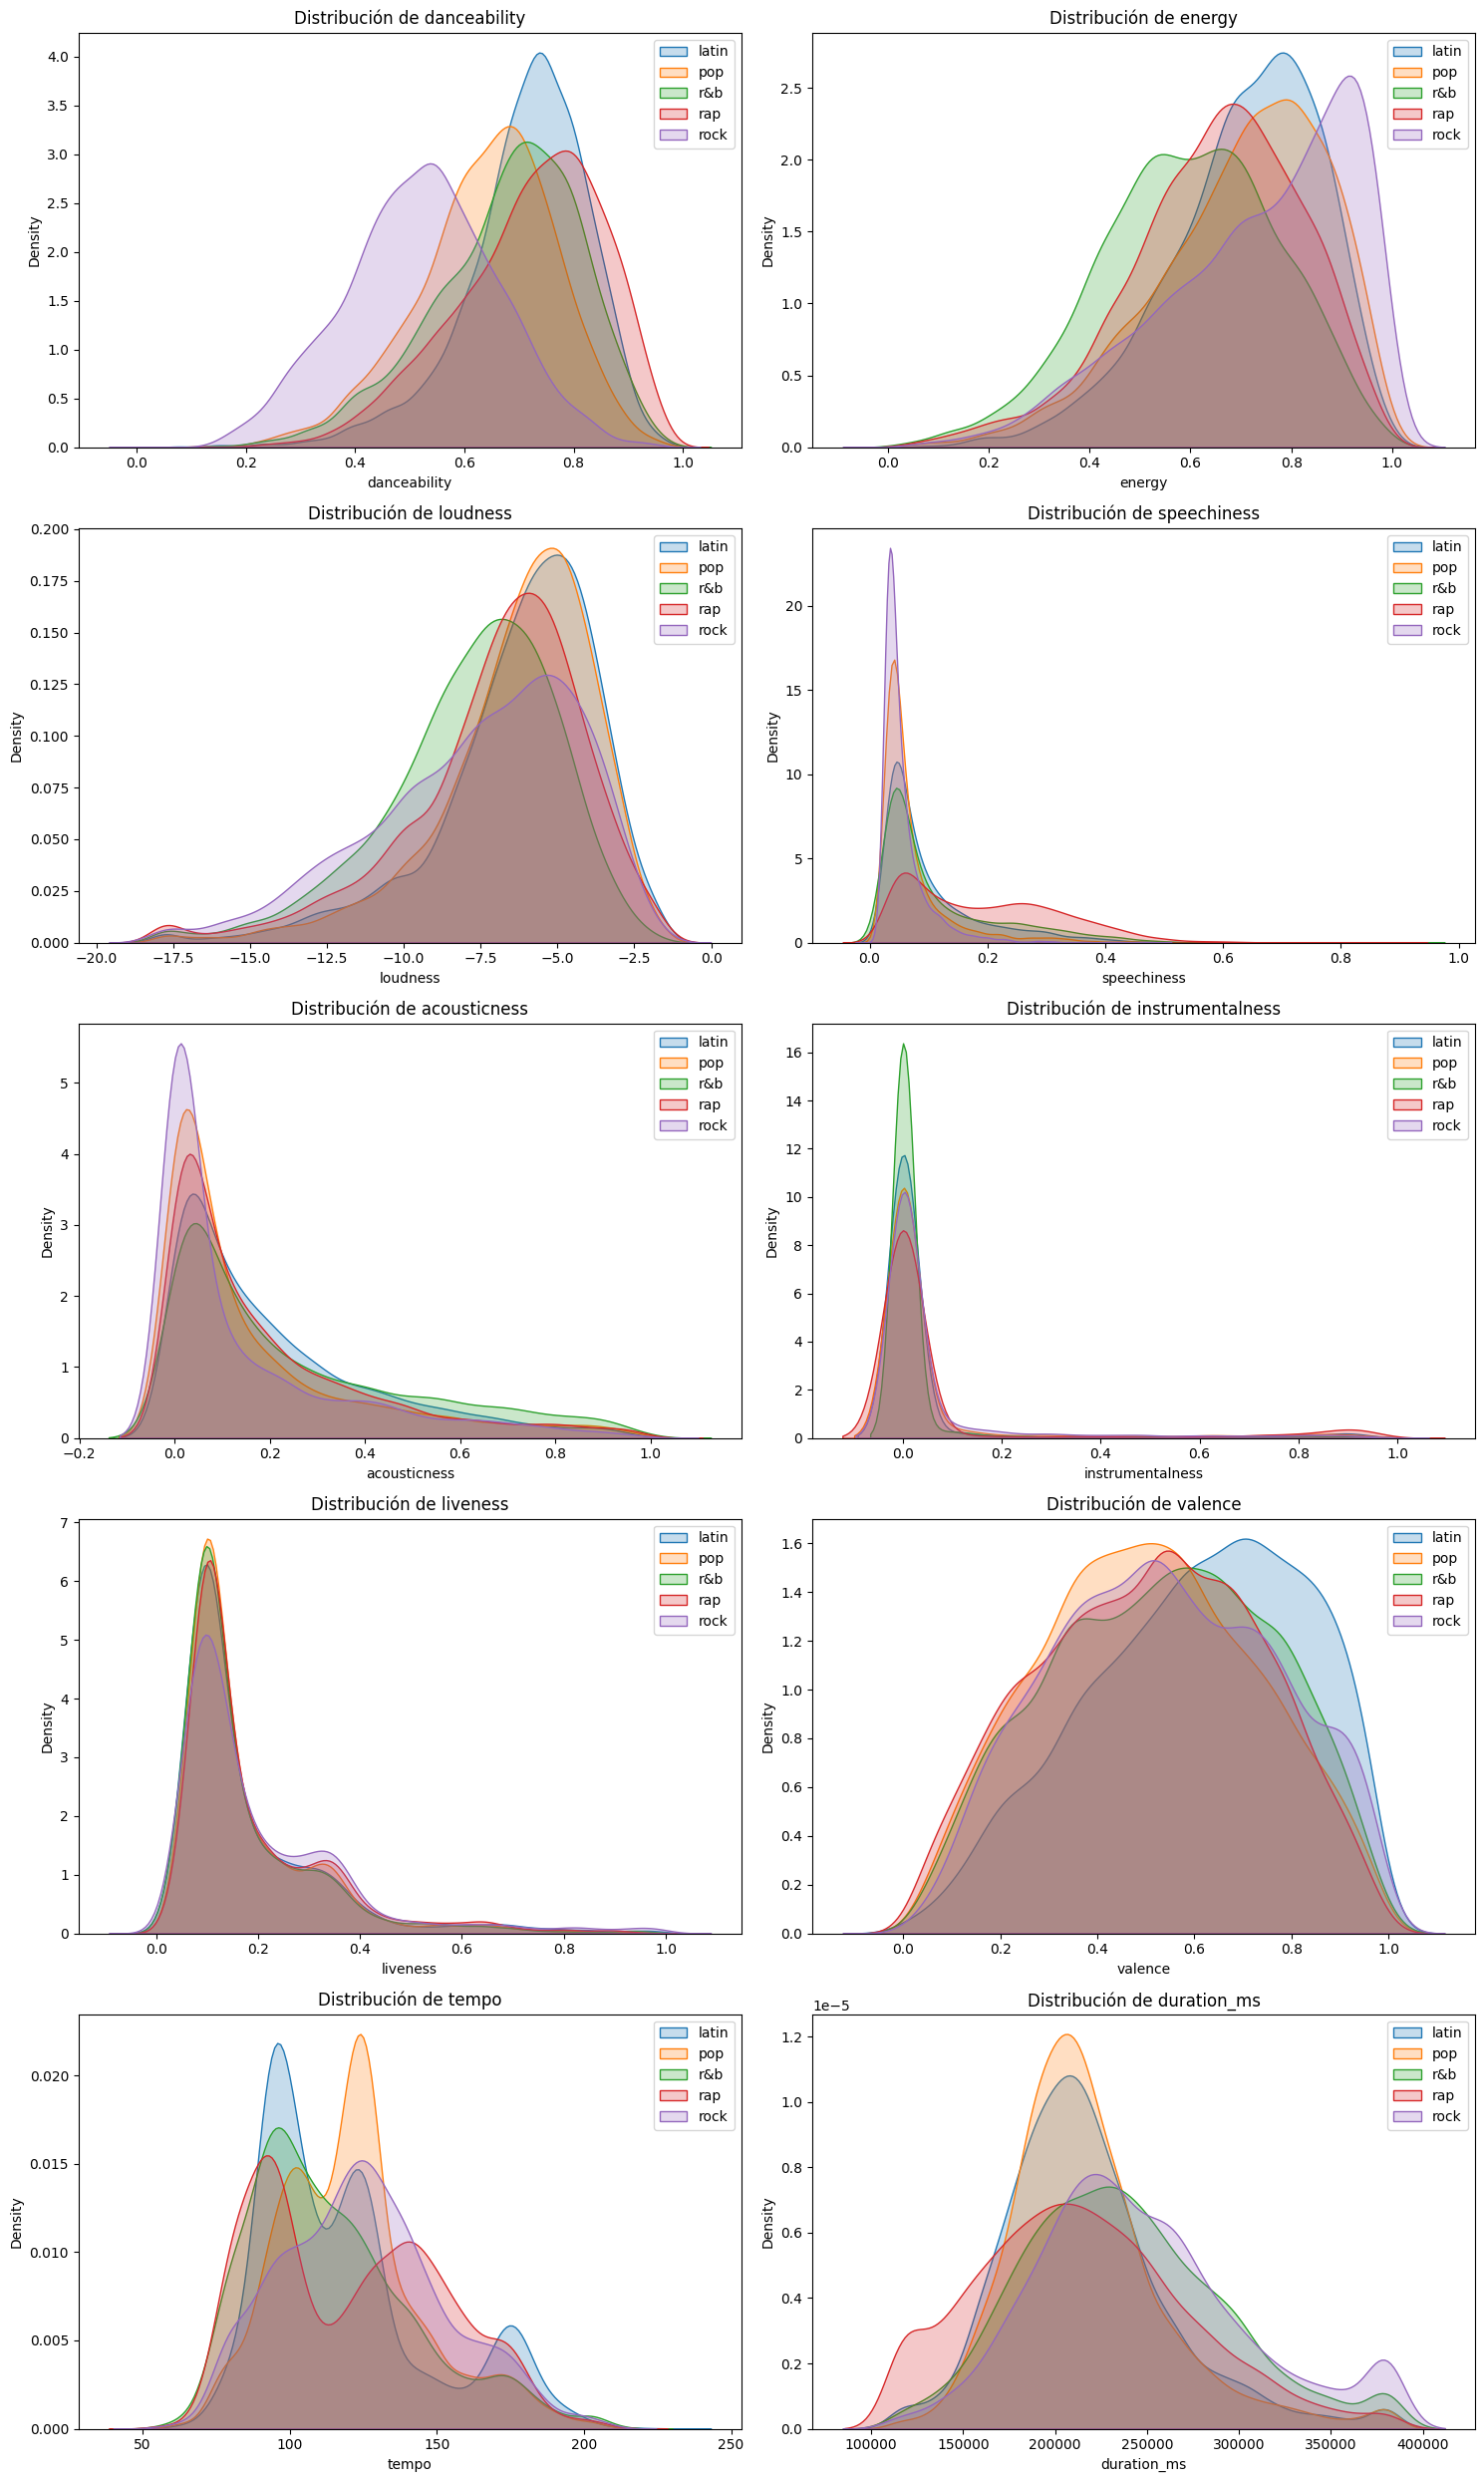

In [243]:
# Configuramos el tamaño de la figura según la cantidad de variables
n_cols = 2
n_rows = (len(numericas) + 1) // n_cols
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numericas):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(df.loc[df['playlist_genre'] == 'latin',col], label='latin', shade=True)
    sns.kdeplot(df.loc[df['playlist_genre'] == 'pop',col], label='pop', shade=True)
    sns.kdeplot(df.loc[df['playlist_genre'] == 'r&b',col], label='r&b', shade=True)
    sns.kdeplot(df.loc[df['playlist_genre'] == 'rap',col], label='rap', shade=True)
    sns.kdeplot(df.loc[df['playlist_genre'] == 'rock',col], label='rock', shade=True)
    plt.title(f'Distribución de {col}')
    plt.legend()

plt.tight_layout()
plt.show()

### Playlist_subgenre

In [244]:
df['playlist_subgenre'].value_counts()

,count
playlist_subgenre,
southern hip hop,1675
indie poptimism,1672
latin hip hop,1656
hard rock,1485
gangster rap,1458
electropop,1408
urban contemporary,1405
hip hop,1322
dance pop,1298


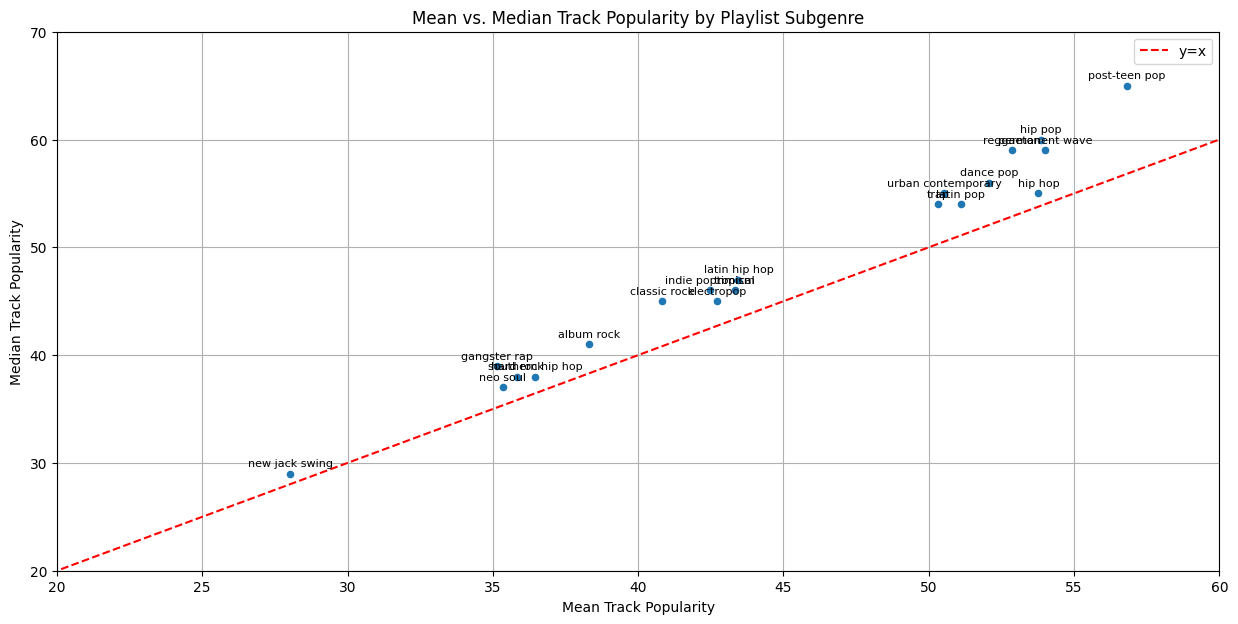

In [245]:
grouped_data = df.groupby(['playlist_subgenre'])['track_popularity'].describe()[['mean', '50%']]

ax = grouped_data.plot(kind='scatter', x='mean', y='50%', figsize=(15, 7))

for i, row in grouped_data.iterrows():
    ax.annotate(i, (row['mean'], row['50%']), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='y=x')
plt.title('Mean vs. Median Track Popularity by Playlist Subgenre')
plt.xlabel('Mean Track Popularity')
plt.ylabel('Median Track Popularity')
plt.grid(True)
plt.legend()
plt.xlim(20,60)
plt.ylim(20,70)
plt.show()

### Analisis otras

Analisis track_popularity

In [246]:
df['track_popularity'].value_counts().head()

,count
track_popularity,
0,1900
60,464
57,463
54,452
61,433


<Axes: ylabel='Frequency'>

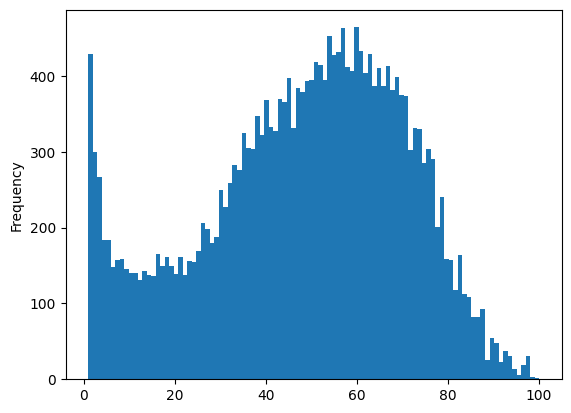

In [247]:
df[df['track_popularity'] != 0]['track_popularity'].plot(kind='hist', bins=100)

#### mode

In [248]:
df['mode'].value_counts()

,count
mode,
1,15181
0,11085


<Axes: xlabel='mode', ylabel='track_popularity'>

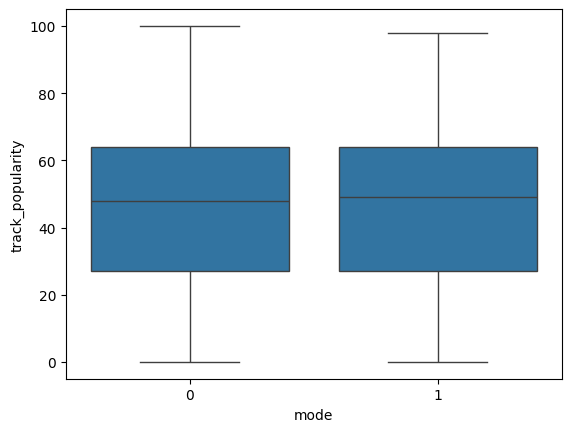

In [249]:
sns.boxplot(data=df, x='mode', y='track_popularity')

#### key

<Axes: xlabel='key', ylabel='count'>

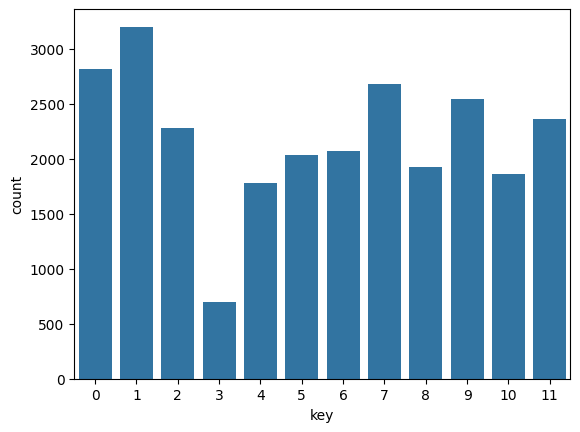

In [250]:
sns.countplot(data=df, x='key')

<Axes: xlabel='key', ylabel='track_popularity'>

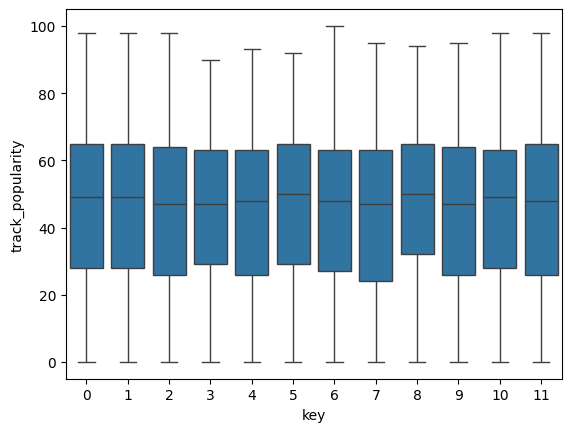

In [251]:
sns.boxplot(data=df, x='key', y='track_popularity')

## Relaciones con la target

### Popularity = 0

In [252]:
df['es0'] = (df['track_popularity'] == 0).astype(int)

In [253]:
crosstab_0_genre = pd.crosstab(df['playlist_genre'], df['es0'], normalize='columns')
crosstab_0_genre['dif'] = crosstab_0_genre[1] - crosstab_0_genre[0]
crosstab_0_genre.sort_values(by='dif', ascending=False)

es0,0,1,dif
playlist_genre,,,
r&b,0.184684,0.214211,0.029527
rock,0.187228,0.204737,0.017509
rap,0.217927,0.229474,0.011547
latin,0.196996,0.186842,-0.010154
pop,0.213166,0.164737,-0.048429


- Pop tienen menos porcentaje de canciones con track_popularity 0 que otros generos
- El que mas tiene es r&b

In [254]:
crosstab_1_genre = pd.crosstab(df['playlist_genre'], df['es0'], normalize='index')
crosstab_1_genre['dif'] = crosstab_1_genre[1] - crosstab_1_genre[0]
crosstab_1_genre.sort_values(by='dif', ascending=False)

es0,0,1,dif
playlist_genre,,,
r&b,0.917057,0.082943,-0.834115
rock,0.921430,0.078570,-0.842860
rap,0.924121,0.075879,-0.848242
latin,0.931135,0.068865,-0.862270
pop,0.943163,0.056837,-0.886326


In [255]:
crosstab_0_subgenre = pd.crosstab(df['playlist_subgenre'], df['es0'], normalize='columns')
crosstab_0_subgenre['dif'] = crosstab_0_subgenre[1] - crosstab_0_subgenre[0]
crosstab_0_subgenre.sort_values(by='dif', ascending=False)

es0,0,1,dif
playlist_subgenre,,,
gangster rap,0.050152,0.124211,0.074059
new jack swing,0.038209,0.106316,0.068107
latin hip hop,0.059879,0.103684,0.043806
album rock,0.038578,0.065789,0.027211
hard rock,0.054748,0.079474,0.024725
electropop,0.051876,0.075789,0.023914
southern hip hop,0.062300,0.082632,0.020332
neo soul,0.041369,0.055263,0.013894
reggaeton,0.035911,0.038947,0.003037


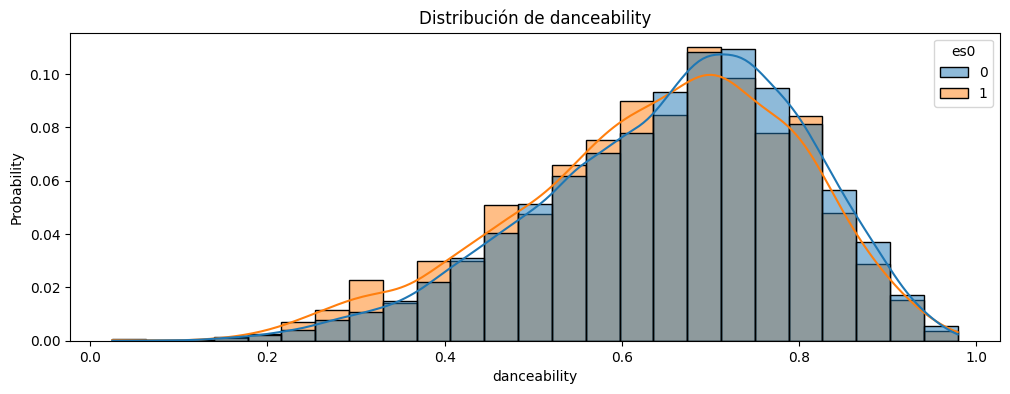

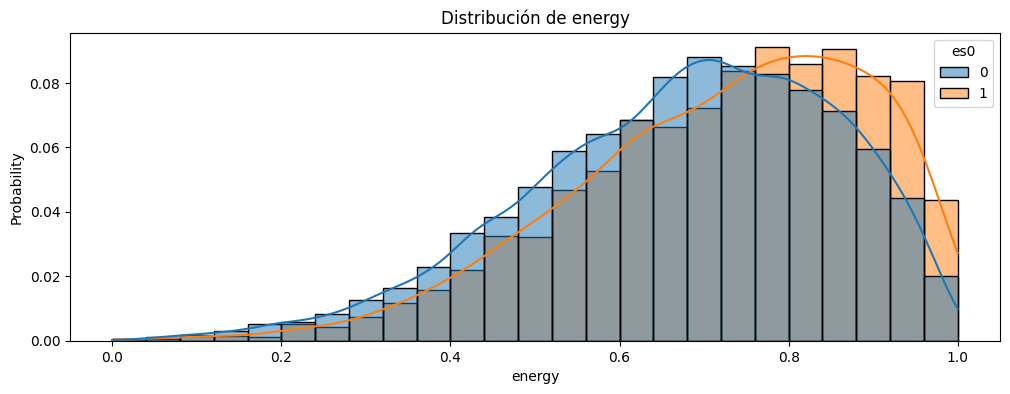

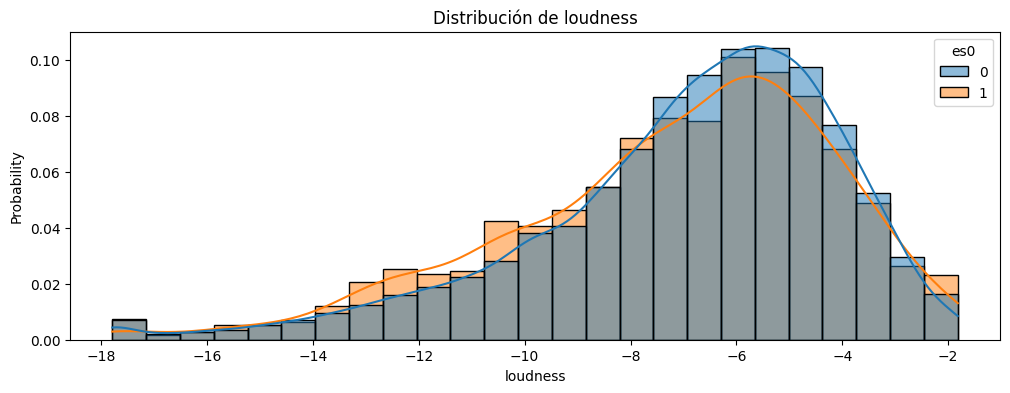

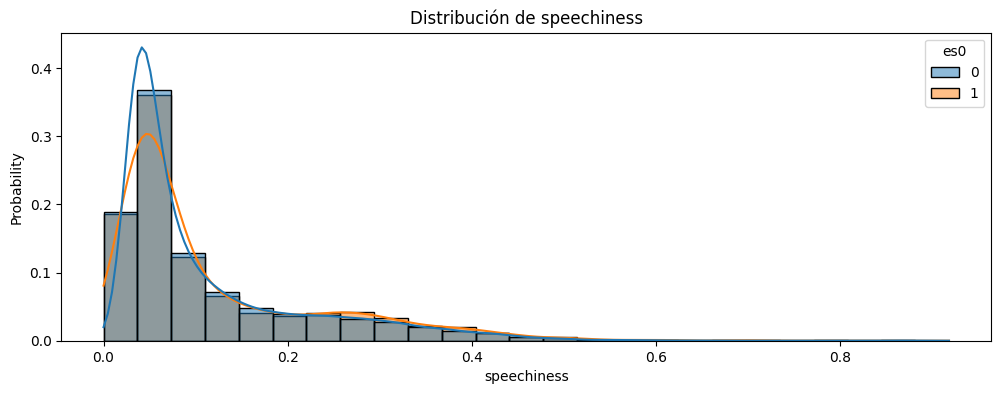

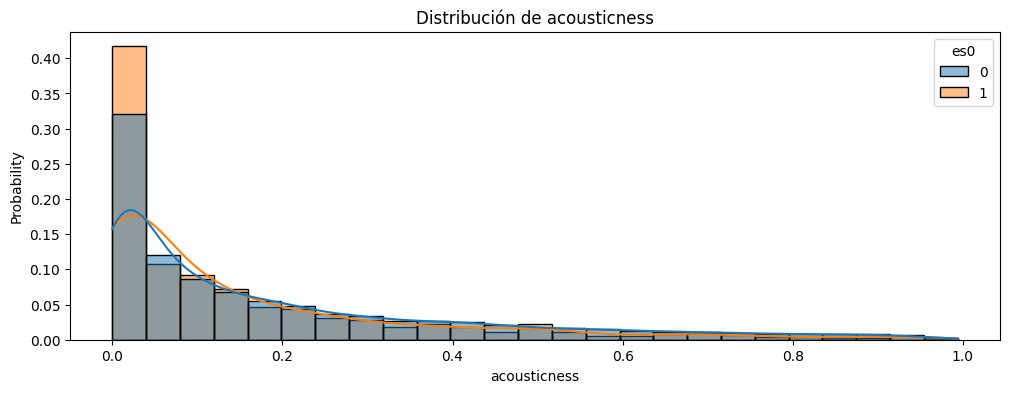

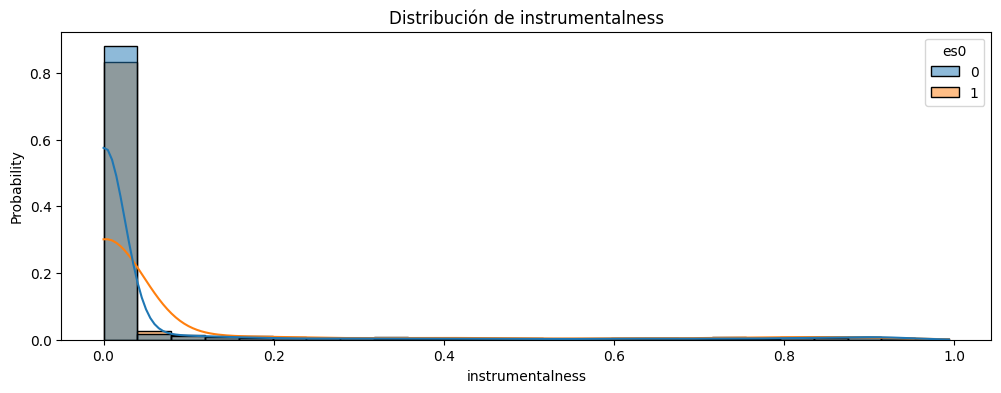

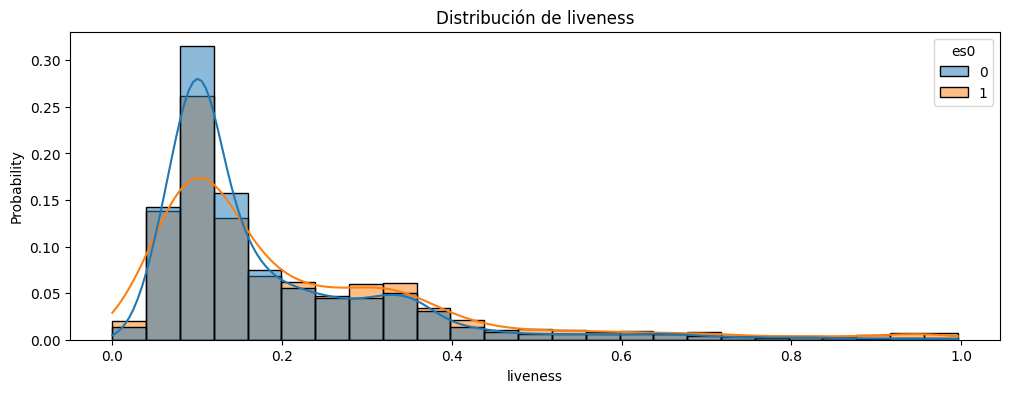

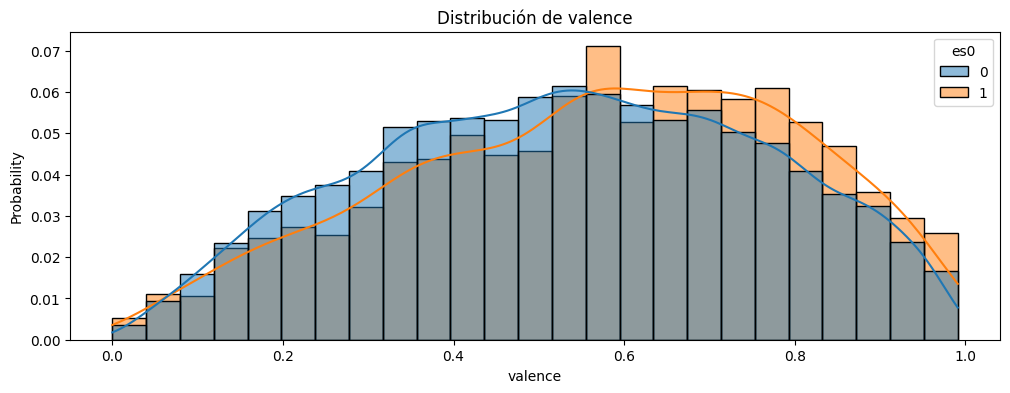

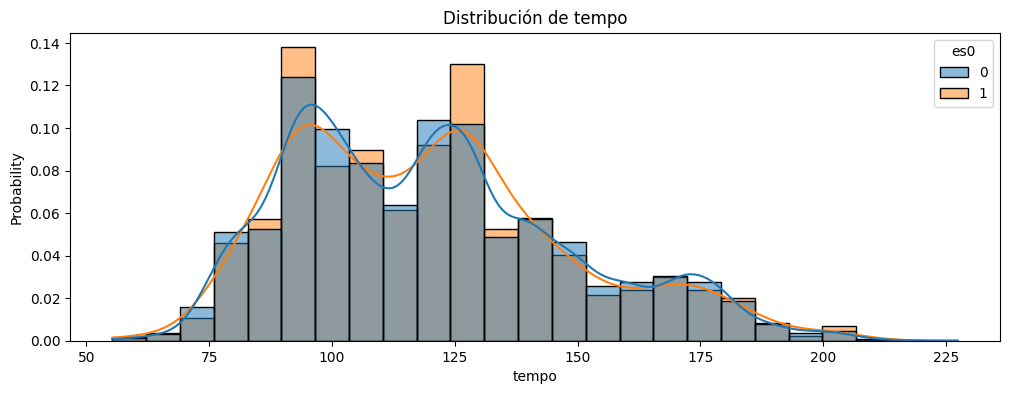

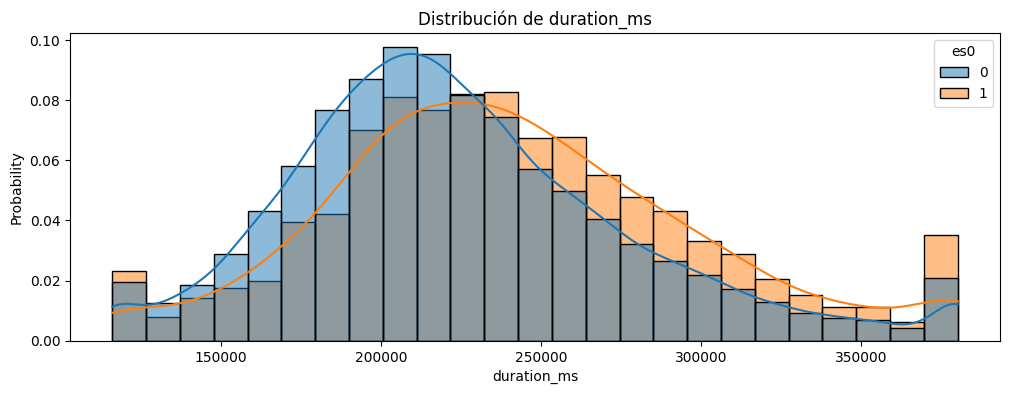

In [256]:
for col in numericas:
  plt.figure(figsize=(12,4))
  sns.histplot(data=df, x=col, hue='es0', bins=25, kde=True, stat='probability', common_norm=False)
  plt.title(f"Distribución de {col}")
  plt.axhline
  plt.show()

<Axes: >

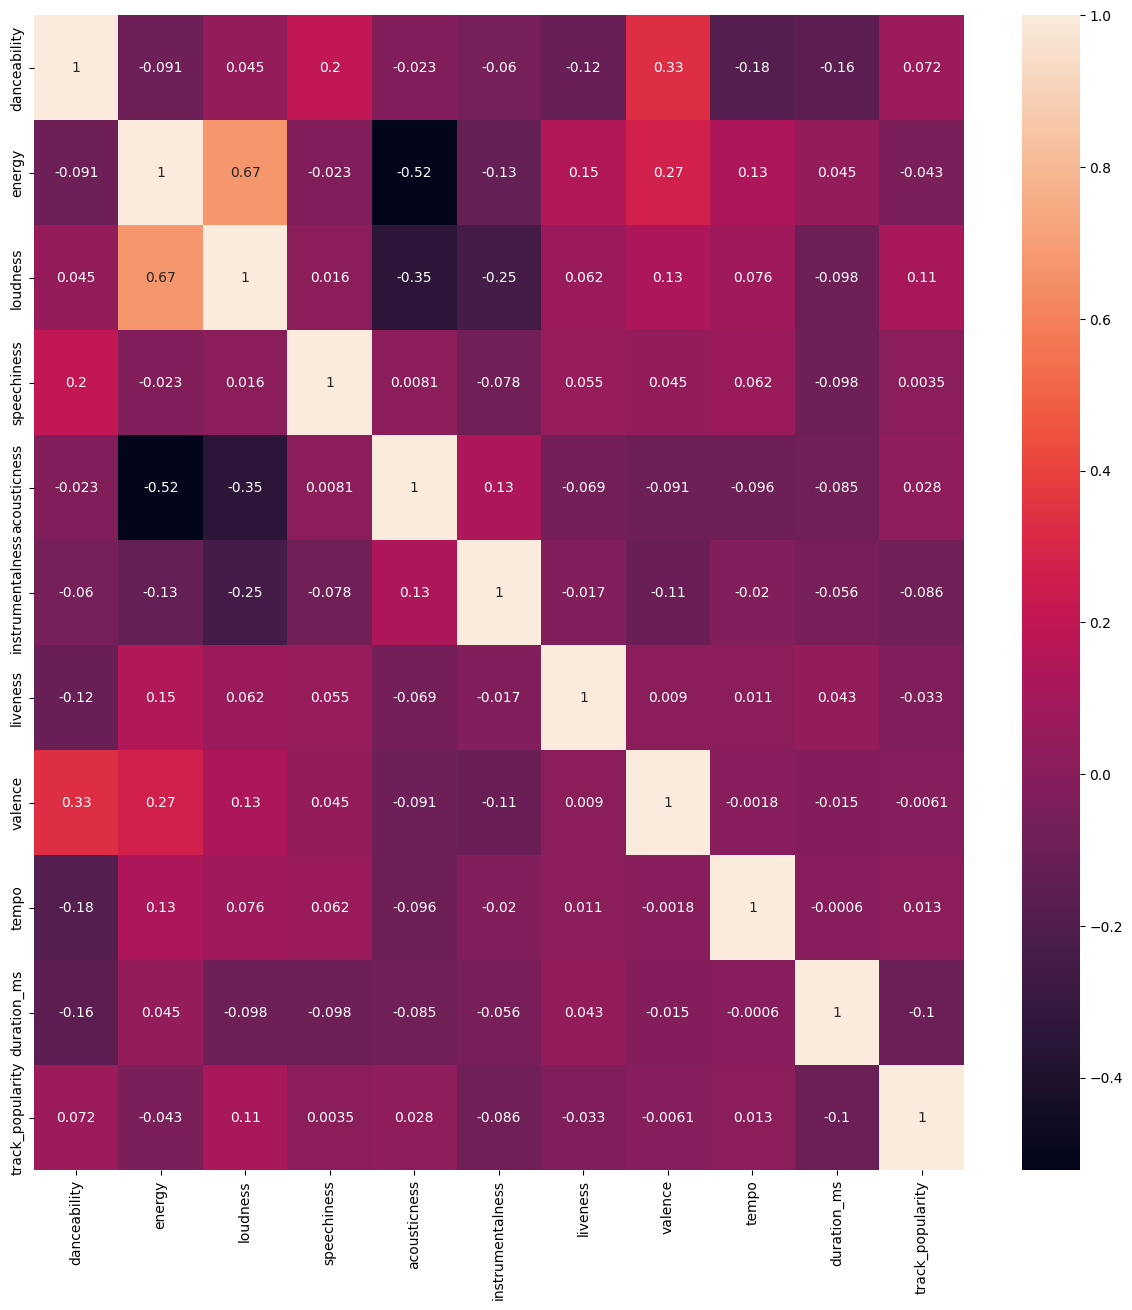

In [257]:
plt.figure(figsize=(15,15))
sns.heatmap(df[~(df['track_popularity'].isin([0,1,99,100]))][numericas+['track_popularity']].corr(), annot=True)

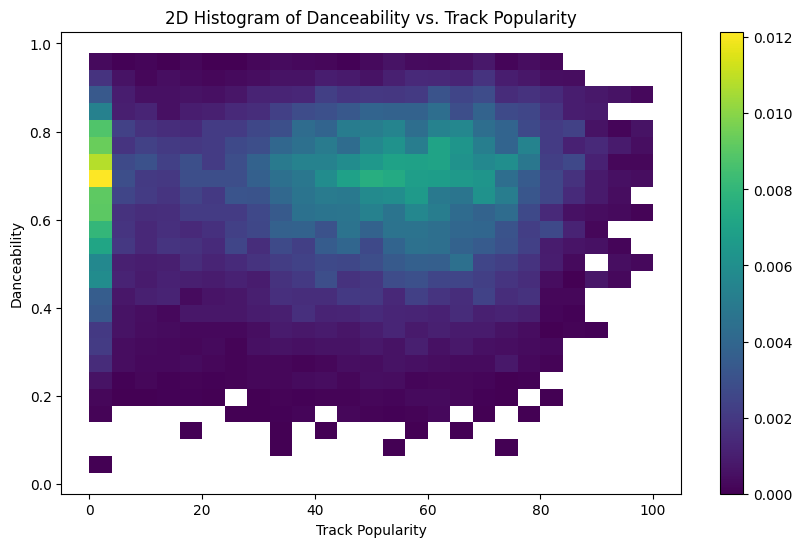

In [258]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='track_popularity', y='danceability', bins=25, cmap='viridis', cbar=True, stat='probability')
plt.title('2D Histogram of Danceability vs. Track Popularity')
plt.xlabel('Track Popularity')
plt.ylabel('Danceability')
plt.show()

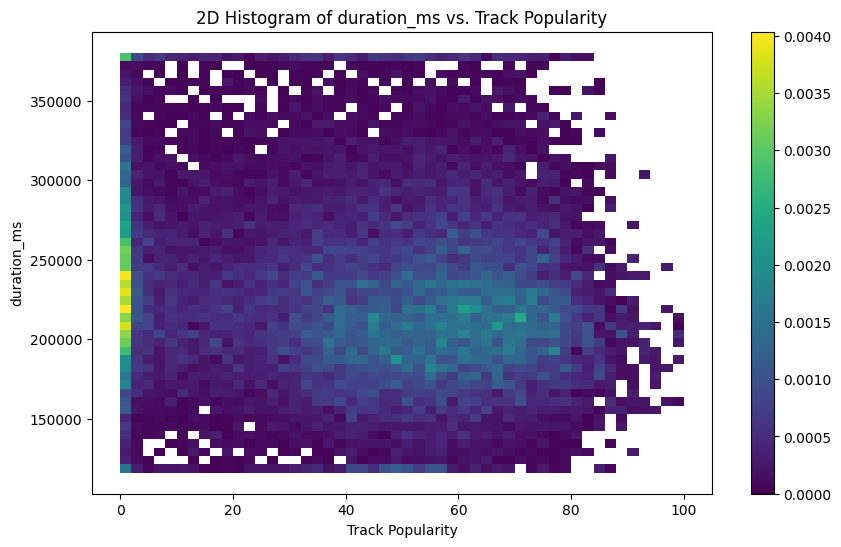

In [259]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='track_popularity', y='duration_ms', bins=50, cmap='viridis', cbar=True, stat='probability', common_norm=True)
plt.title('2D Histogram of duration_ms vs. Track Popularity')
plt.xlabel('Track Popularity')
plt.ylabel('duration_ms')
plt.show()

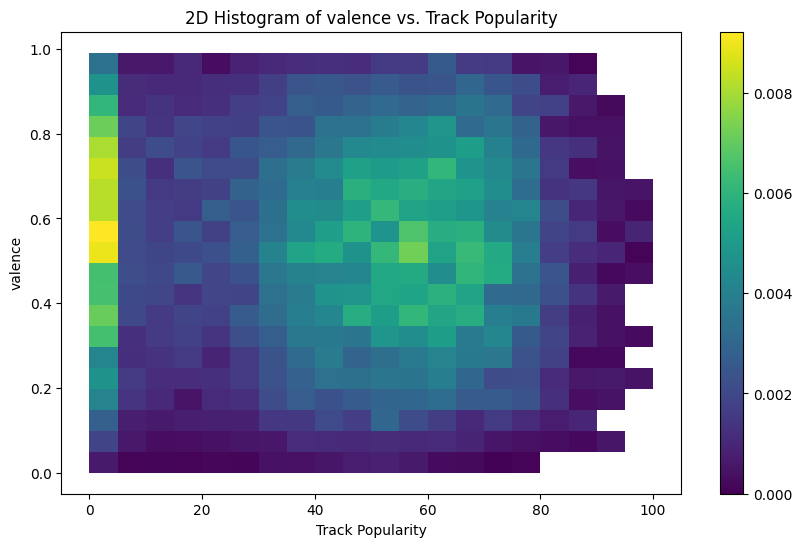

In [260]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='track_popularity', y='valence', bins=20, cmap='viridis', cbar=True, stat='probability')
plt.title('2D Histogram of valence vs. Track Popularity')
plt.xlabel('Track Popularity')
plt.ylabel('valence')
plt.show()

### Popularity por rangos

In [261]:
df['track_popularity_bins'] = pd.cut(df['track_popularity'], bins=10)

Vemos lo siguiente:

- +danceability -> +popularity
- +energy -> -popularity
- loudness -> no parece influir
- +speechiness -> +popularity
- +acousticness -> +popularity
- instrumentalness -> no aporta info
- +liveness -> -popularidad (pero poco confiable por alto DESV EST)
- +valence -> -popularity
- tempo -> no aporta info
- +duration_ms -> -popularity

In [262]:
df.groupby(['track_popularity_bins'])[numericas].describe()

danceability                                        \
                             count      mean       std       min     25%   
track_popularity_bins                                                      
(-0.1, 10.0]                4009.0  0.641650  0.154799  0.025033  0.5420   
(10.0, 20.0]                1451.0  0.641436  0.147222  0.118000  0.5430   
(20.0, 30.0]                1798.0  0.652603  0.140323  0.162000  0.5610   
(30.0, 40.0]                3014.0  0.649344  0.148644  0.098500  0.5570   
(40.0, 50.0]                3671.0  0.653246  0.150097  0.116000  0.5615   
(50.0, 60.0]                4283.0  0.654634  0.150569  0.078700  0.5550   
(60.0, 70.0]                4017.0  0.663282  0.151640  0.135000  0.5620   
(70.0, 80.0]                2814.0  0.665059  0.148237  0.077100  0.5660   
(80.0, 90.0]                 996.0  0.702423  0.127633  0.209000  0.6120   
(90.0, 100.0]                213.0  0.714009  0.124020  0.474000  0.6540   

                                            energy                      \
                         50%    75%    max   count      mean       std   
track_popularity_bins                                                    
(-0.1, 10.0]           0.662  0.759  0.975  4009.0  0.708576  0.178477   
(10.0, 20.0]           0.659  0.747  0.959  1451.0  0.688514  0.173325   
(20.0, 30.0]           0.672  0.757  0.977  1798.0  0.680131  0.175791   
(30.0, 40.0]           0.669  0.758  0.967  3014.0  0.674238  0.185335   
(40.0, 50.0]           0.674  0.764  0.974  3671.0  0.667212  0.189972   
(50.0, 60.0]           0.675  0.764  0.978  4283.0  0.667970  0.187710   
(60.0, 70.0]           0.682  0.775  0.979  4017.0  0.675168  0.174751   
(70.0, 80.0]           0.685  0.774  0.975  2814.0  0.682598  0.161928   
(80.0, 90.0]           0.719  0.796  0.974   996.0  0.643418  0.155448   
(90.0, 100.0]          0.724  0.803  0.896   213.0  0.585653  0.152937   

                                                                 loudness  \
                            min      25%     50%      75%    max    count   
track_popularity_bins                                                       
(-0.1, 10.0]           0.016100  0.59300  0.7340  0.85100  0.999   4009.0   
(10.0, 20.0]           0.127000  0.58050  0.7030  0.82300  0.993   1451.0   
(20.0, 30.0]           0.032300  0.56125  0.6970  0.81775  0.996   1798.0   
(30.0, 40.0]           0.008140  0.54800  0.6930  0.82375  0.998   3014.0   
(40.0, 50.0]           0.011800  0.54600  0.6940  0.81500  0.999   3671.0   
(50.0, 60.0]           0.000175  0.54400  0.6890  0.81400  1.000   4283.0   
(60.0, 70.0]           0.058100  0.56000  0.6970  0.80600  0.993   4017.0   
(70.0, 80.0]           0.016700  0.58125  0.7015  0.80100  1.000   2814.0   
(80.0, 90.0]           0.056100  0.53800  0.6520  0.75925  0.972    996.0   
(90.0, 100.0]          0.225000  0.45700  0.6090  0.71500  0.808    213.0   

                                                                       \
                           mean       std        min      25%     50%   
track_popularity_bins                                                   
(-0.1, 10.0]          -7.109036  3.014334 -17.786507 -8.83800 -6.5340   
(10.0, 20.0]          -7.343487  2.953061 -17.786507 -8.91850 -6.8830   
(20.0, 30.0]          -7.363524  2.951893 -17.786507 -8.76500 -6.7920   
(30.0, 40.0]          -7.252158  2.947006 -17.786507 -8.81000 -6.7865   
(40.0, 50.0]          -7.293269  3.079635 -17.786507 -8.86750 -6.6970   
(50.0, 60.0]          -7.122503  3.034876 -17.786507 -8.66650 -6.5610   
(60.0, 70.0]          -6.681080  2.781301 -17.786507 -8.10600 -6.1190   
(70.0, 80.0]          -6.172051  2.547083 -17.786507 -7.28975 -5.7625   
(80.0, 90.0]          -5.960580  2.449910 -17.786507 -7.15900 -5.6125   
(90.0, 100.0]         -6.373211  2.336257 -14.454000 -7.20900 -5.9800   

                                         speechiness                      \
                           75%       max  

In [263]:
# El primer intervalo sin los valores que son 0
pd.DataFrame(df[~(df['track_popularity'] == 0)].groupby(['track_popularity_bins'])[numericas].describe().iloc[0,:]).T

danceability                                                      \
                    count      mean     std    min   25%    50%    75%    max   
(-0.1, 10.0]       2109.0  0.644088  0.1545  0.166  0.54  0.668  0.762  0.975   

              energy                                                          \
               count      mean       std     min    25%    50%    75%    max   
(-0.1, 10.0]  2109.0  0.696541  0.180676  0.0161  0.579  0.718  0.843  0.997   

             loudness                                                     \
                count      mean      std        min    25%    50%    75%   
(-0.1, 10.0]   2109.0 -6.997753  2.95366 -17.786507 -8.634 -6.458 -4.864   

                       speechiness                                      \
                   max       count      mean       std     min     25%   
(-0.1, 10.0] -1.819814      2109.0  0.108907  0.104763  0.0224  0.0398   

                                  acousticness                                \
                 50%    75%   max        count      mean       std       min   
(-0.1, 10.0]  0.0628  0.136  0.86       2109.0  0.175841  0.216498  0.000007   

                                          instrumentalness            \
                 25%     50%   75%    max            count      mean   
(-0.1, 10.0]  0.0164  0.0835  0.25  0.994           2109.0  0.067185   

                                                           liveness            \
                   std  min  25%       50%      75%    max    count      mean   
(-0.1, 10.0]  0.195884  0.0  0.0  0.000016  0.00402  0.969   2109.0  0.186777   

                                                           valence            \
                   std    min     25%    50%    75%    max   count      mean   
(-0.1, 10.0]  0.149241  0.015  0.0902  0.129  0.254  0.991  2109.0  0.538484   

                                                             tempo  \
                   std     min    25%    50%    75%    max   count   
(-0.1, 10.0]  0.234069  0.0358  0.353  0.548  0.722  0.975  2109.0   

                                                                          \
                    mean        std        min     25%      50%      75%   
(-0.1, 10.0]  119.626851  28.647441  55.289289  96.992  117.159  136.096   

                        duration_ms                               \
                    max       count           mean           std   
(-0.1, 10.0]  227.38185      2109.0  238927.126421  56617.486149   

                                                                          
                        min       25%       50%       75%            max  
(-0.1, 10.0]  116111.393149  201178.0  230693.0  269147.0  380258.706843

In [264]:
pd.concat([pd.DataFrame(df[~(df['track_popularity'] == 0)].groupby(['track_popularity_bins'])[numericas].describe().iloc[0,:]).T , df.groupby(['track_popularity_bins'])[numericas].describe()], axis=0).iloc[:2,:]

danceability                                                     \
                    count      mean       std       min    25%    50%    75%   
(-0.1, 10.0]       2109.0  0.644088  0.154500  0.166000  0.540  0.668  0.762   
(-0.1, 10.0]       4009.0  0.641650  0.154799  0.025033  0.542  0.662  0.759   

                     energy                                                   \
                max   count      mean       std     min    25%    50%    75%   
(-0.1, 10.0]  0.975  2109.0  0.696541  0.180676  0.0161  0.579  0.718  0.843   
(-0.1, 10.0]  0.975  4009.0  0.708576  0.178477  0.0161  0.593  0.734  0.851   

                    loudness                                               \
                max    count      mean       std        min    25%    50%   
(-0.1, 10.0]  0.997   2109.0 -6.997753  2.953660 -17.786507 -8.634 -6.458   
(-0.1, 10.0]  0.999   4009.0 -7.109036  3.014334 -17.786507 -8.838 -6.534   

                              speechiness                                      \
                75%       max       count      mean       std     min     25%   
(-0.1, 10.0] -4.864 -1.819814      2109.0  0.108907  0.104763  0.0224  0.0398   
(-0.1, 10.0] -4.913 -1.819814      4009.0  0.113703  0.109273  0.0000  0.0402   

                                  acousticness                                \
                 50%    75%   max        count      mean       std       min   
(-0.1, 10.0]  0.0628  0.136  0.86       2109.0  0.175841  0.216498  0.000007   
(-0.1, 10.0]  0.0638  0.146  0.86       4009.0  0.164863  0.209934  0.000000   

                                           instrumentalness            \
                 25%     50%    75%    max            count      mean   
(-0.1, 10.0]  0.0164  0.0835  0.250  0.994           2109.0  0.067185   
(-0.1, 10.0]  0.0145  0.0774  0.233  0.994           4009.0  0.069310   

                                                           liveness            \
                   std  min  25%       50%      75%    max    count      mean   
(-0.1, 10.0]  0.195884  0.0  0.0  0.000016  0.00402  0.969   2109.0  0.186777   
(-0.1, 10.0]  0.197862  0.0  0.0  0.000016  0.00431  0.970   4009.0  0.200824   

                                                           valence            \
                   std    min     25%    50%    75%    max   count      mean   
(-0.1, 10.0]  0.149241  0.015  0.0902  0.129  0.254  0.991  2109.0  0.538484   
(-0.1, 10.0]  0.168124  0.000  0.0924  0.134  0.272  0.991  4009.0  0.553197   

                                                             tempo  \
                   std     min    25%    50%    75%    max   count   
(-0.1, 10.0]  0.234069  0.0358  0.353  0.548  0.722  0.975  2109.0   
(-0.1, 10.0]  0.232400  0.0000  0.374  0.566  0.738  0.977  4009.0   

                                                                          \
                    mean        std        min     25%      50%      75%   
(-0.1, 10.0]  119.626851  28.647441  55.289289  96.992  117.159  136.096   
(-0.1, 10.0]  119.745342  28.492679  55.289289  96.382  117.973  136.004   

                        duration_ms                               \
                    max       count           mean           std   
(-0.1, 10.0]  227.38185      2109.0  238927.126421  56617.486149   
(-0.1, 10.0]  227.38185      4009.0  239863.768526  56843.463432   

                                                                          
                        min       25%       50%       75%            max  
(-0.1, 10.0]  116111.393149  201178.0  230693.0  269147.0  380258.706843  
(-0.1, 10.0]  116111.393149  201911.0  233430.0  271766.0  380258.706843

### Playlist_genre y track_popularity_bins

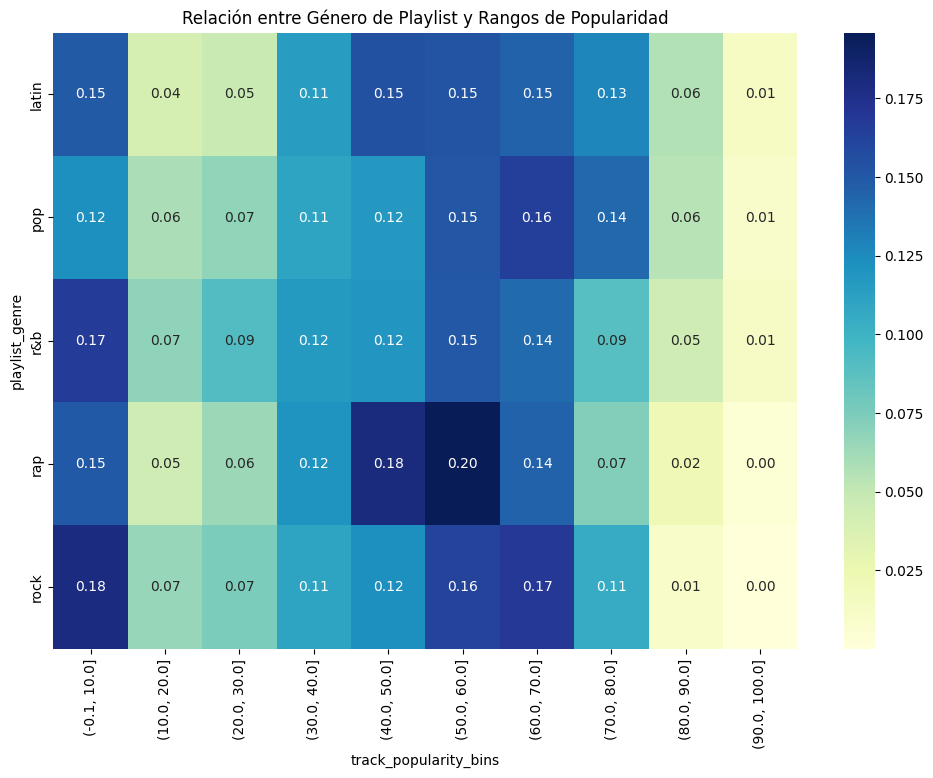

In [265]:
plt.figure(figsize=(12, 8))
sns.heatmap(pd.crosstab(df['playlist_genre'], df['track_popularity_bins'], normalize='index'), annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Relación entre Género de Playlist y Rangos de Popularidad')
plt.show()

# Base Validación

### Conocimiento Base

In [124]:
df_val.shape

(6567, 23)

In [125]:
df_val.head()

,Unnamed: 0,track_id,track_name,track_artist,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,26266,7PaMBn99pOcj8YAlOHNDuqB3e1aK1qYARo6n8INLYuu+BR...,173KRCcCzJjxgoO/mpxgIKdDk8RvN/RzJdwQ3YZ2V1o=,tVfzlga75csdmmwX2fvsaDbNVu3Bcd+mtiSdeY3ZAII=,NkCWRp8NfQzBz8vuI0fq4KVgXTjbCGZyVkTy8y7pCFtTMj...,wtAQ56qXHQIOmQVkU+NhnpEsGuNbkeshj547IN74Eyo=,2016-08-04,6EoyCJcDz8HlLgXlJSDfAK9I/6pbZ3UuJRQ1y6UNAyQQmK...,80chKBTjiSD2eezS8TujTcQjYNJeTQ7k1bTaF1Gbarfwrm...,r&b,neo soul,0.783,0.882,0,-4.986,1,0.1560,0.000085,0.004680,0.271,0.865,117.062,214359
1,26267,9nQmZDq5zCw3zKqGOFAJrur9SAtvb+wGJW6zhNPEVlt61k...,iWcyPklNFqzBjbCKWYFlku6EaIrBV9CwHwuRG9sMXiM=,tVfzlga75csdmmwX2fvsaDbNVu3Bcd+mtiSdeY3ZAII=,cpp5tCc6t4cstM+09I4e/9ttEcVuRkQ7Oei42WEyOpBuEW...,o4G9l6dD4Nd+myuU0EeQq41k0uqBpCrSgzWwMisG828=,2017-02-24,6EoyCJcDz8HlLgXlJSDfAK9I/6pbZ3UuJRQ1y6UNAyQQmK...,80chKBTjiSD2eezS8TujTcQjYNJeTQ7k1bTaF1Gbarfwrm...,r&b,neo soul,0.718,0.912,5,-5.757,0,0.2840,0.040400,0.000280,0.195,0.798,118.198,195254
2,26268,KkRqMpdvuz0AdyZzBtHirWl/9rgqbfNmpCOC6dEiezJJjR...,9kEQ17NfC/GeewWtkljXdT/hftSet9UXsZrEpG1QLWI=,tVfzlga75csdmmwX2fvsaDbNVu3Bcd+mtiSdeY3ZAII=,cpp5tCc6t4cstM+09I4e/9ttEcVuRkQ7Oei42WEyOpBuEW...,o4G9l6dD4Nd+myuU0EeQq41k0uqBpCrSgzWwMisG828=,2017-02-24,6EoyCJcDz8HlLgXlJSDfAK9I/6pbZ3UuJRQ1y6UNAyQQmK...,80chKBTjiSD2eezS8TujTcQjYNJeTQ7k1bTaF1Gbarfwrm...,r&b,neo soul,0.756,0.935,1,-7.150,1,0.2190,0.088500,0.000336,0.308,0.843,116.977,201026
3,26269,sgTJ5rFQWLhi7GCYdjD9r3QvajD5LK1HOpTeoHW2iBf/Co...,7Z+tOM/PJUP9O/Ks//GmqMfNVGXz9PpOqiuhrQJhf/dhy8...,tVfzlga75csdmmwX2fvsaDbNVu3Bcd+mtiSdeY3ZAII=,QLcNTQq4ZbHSN6RxzRsTwiWJmg2IQMSw2HBYfCXX+LFL8a...,7Z+tOM/PJUP9O/Ks//GmqMfNVGXz9PpOqiuhrQJhf/dhy8...,2017-11-27,6EoyCJcDz8HlLgXlJSDfAK9I/6pbZ3UuJRQ1y6UNAyQQmK...,80chKBTjiSD2eezS8TujTcQjYNJeTQ7k1bTaF1Gbarfwrm...,r&b,neo soul,0.627,0.818,7,-8.359,1,0.6590,0.024000,0.000000,0.949,0.485,119.996,226500
4,26270,13a/INcHNOt+oILbqtAKxbWZDfXqiksv34uWdZNcMWpz/H...,3iEK2zpdxS2P5ez3V+fFUOm6/S9V2mgikSo4maqit3NhpD...,jrCkmY466u9hEkyxFB/UnoNeCam5kFZxGmz9ATPDgmM=,utzH6uUW76IRGHy+odr95qvpF4a7SRGOUrqhltV+st+HtG...,E7tuY6aI3UEDy9yrjv9R2XfGueH58N6uPEDbCD2hP0I=,2015-10-21,6EoyCJcDz8HlLgXlJSDfAK9I/6pbZ3UuJRQ1y6UNAyQQmK...,80chKBTjiSD2eezS8TujTcQjYNJeTQ7k1bTaF1Gbarfwrm...,r&b,neo soul,0.606,0.793,11,-7.422,0,0.0318,0.006980,0.454000,0.300,0.773,119.986,166000


In [126]:
print('Valores unicos de:')
print(f'track_id: {df_val["track_id"].nunique()}')
print(f'track_name: {df_val["track_name"].nunique()}')
print(f'track_artist: {df_val["track_artist"].nunique()}')
print(f'track_album_id: {df_val["track_album_id"].nunique()}')
print(f'track_album_name: {df_val["track_album_name"].nunique()}')
print(f'playlist_id: {df_val["playlist_id"].nunique()}')
print(f'playlist_name: {df_val["playlist_name"].nunique()}')

Valores unicos de:
track_id: 6060
track_name: 5507
track_artist: 2767
track_album_id: 5513
track_album_name: 4974
playlist_id: 84
playlist_name: 84


### Conversion Fecha

In [127]:
df_val['anio'] = df_val['track_album_release_date'].apply(lambda x: x.split('-')[0])
df_val['anio'] = df_val['anio'].astype(int)

In [128]:
df_val['grupo_anio'] = df_val['anio'].apply(imputacion_anio)

In [129]:
df_val['grupo_anio'].value_counts()

,count
grupo_anio,
2019,2330
2010,1257
2018,796
2017,566
2016,544
2015,497
2000,312
2020,184
1990,38


Comparamos Fechas Train vs Val

<Axes: xlabel='anio', ylabel='Count'>

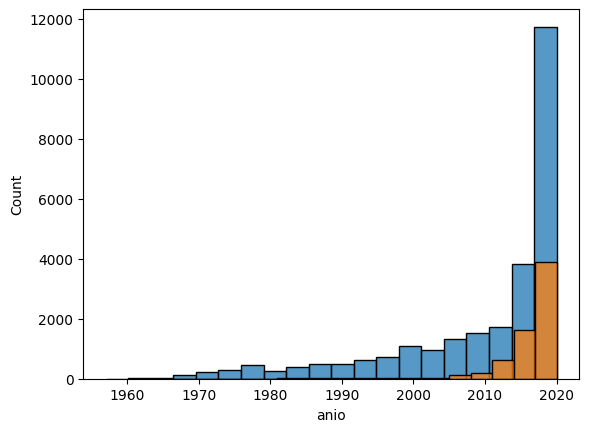

In [167]:
sns.histplot(df['anio'], bins=20)
sns.histplot(df_val['anio'], bins=20)

In [171]:
comparativa_anios = pd.DataFrame({
    'Prop_Train': df['grupo_anio'].value_counts(normalize=True),
    'Prop_Val': df_val['grupo_anio'].value_counts(normalize=True)
}).sort_index()

comparativa_anios['diferencia'] = comparativa_anios['Prop_Train'] - comparativa_anios['Prop_Val']
display(comparativa_anios)

,Prop_Train,Prop_Val,diferencia
grupo_anio,,,
1970,0.042945,0.001980,0.040966
1980,0.048580,0.004568,0.044012
1990,0.086500,0.005787,0.080713
2000,0.143341,0.047510,0.095831
2010,0.122897,0.191412,-0.068515
2015,0.048808,0.075681,-0.026873
2016,0.060268,0.082838,-0.022570
2017,0.070966,0.086189,-0.015222
2018,0.095789,0.121212,-0.025423


### Comparacion distribuciones TRAIN vs VAL

Los comentarios sobre las distribuciones de train habian sido:

**Comentarios**: *Ninguna distribución dio normalidad via test formal*

- Danceability: asimetria a izquierda
- Energy: asimetria a izquierda
- Loudness: asimetria a izquierda, valores menores a -20 son preocupantes si vemos el histograma
- Speechiness: la mayoria estan entre 0.1 y 0.2. Mayores a 0.45 diria de corregir
- Acousticness: lognormal perfecta diria pero parece que está bien, los outliers tienen sentido y son muy graduales
- Instrumentalness: cuidado! valores mayores a 0.1 o parecido son muy muy pocos chequear
- Liveness: podriamos agrupar mayores a 0.5 en ese valor, ya que son pocos en relacion a las frecuencias cercanas a 0.5
- Valence: parece bastantante normal, pero bien robusta, y no tiene outliers
- Tempo: da sensacion de bimodal
- Duration_ms: una normal hermosa, con outliers sobretodo en la parte derecha de la distribucion

Encontramos que:
- Danceability esta mas corrida a la izquierda
- **Energy** esta mucho mas corrida a la derecha
- Loudness un poco mas a la derecha
- Speechiness parecida
- Acousticness muchisimo mas leptocurtica (mas marcada la punta)
- Instrumentalness mucho mas leptocurtica
- Liveness muy parecida
- **Valence** -> totalmente otra distribucion
- **Tempo** -> totalmente otra distribucion
- Duration_ms parecida

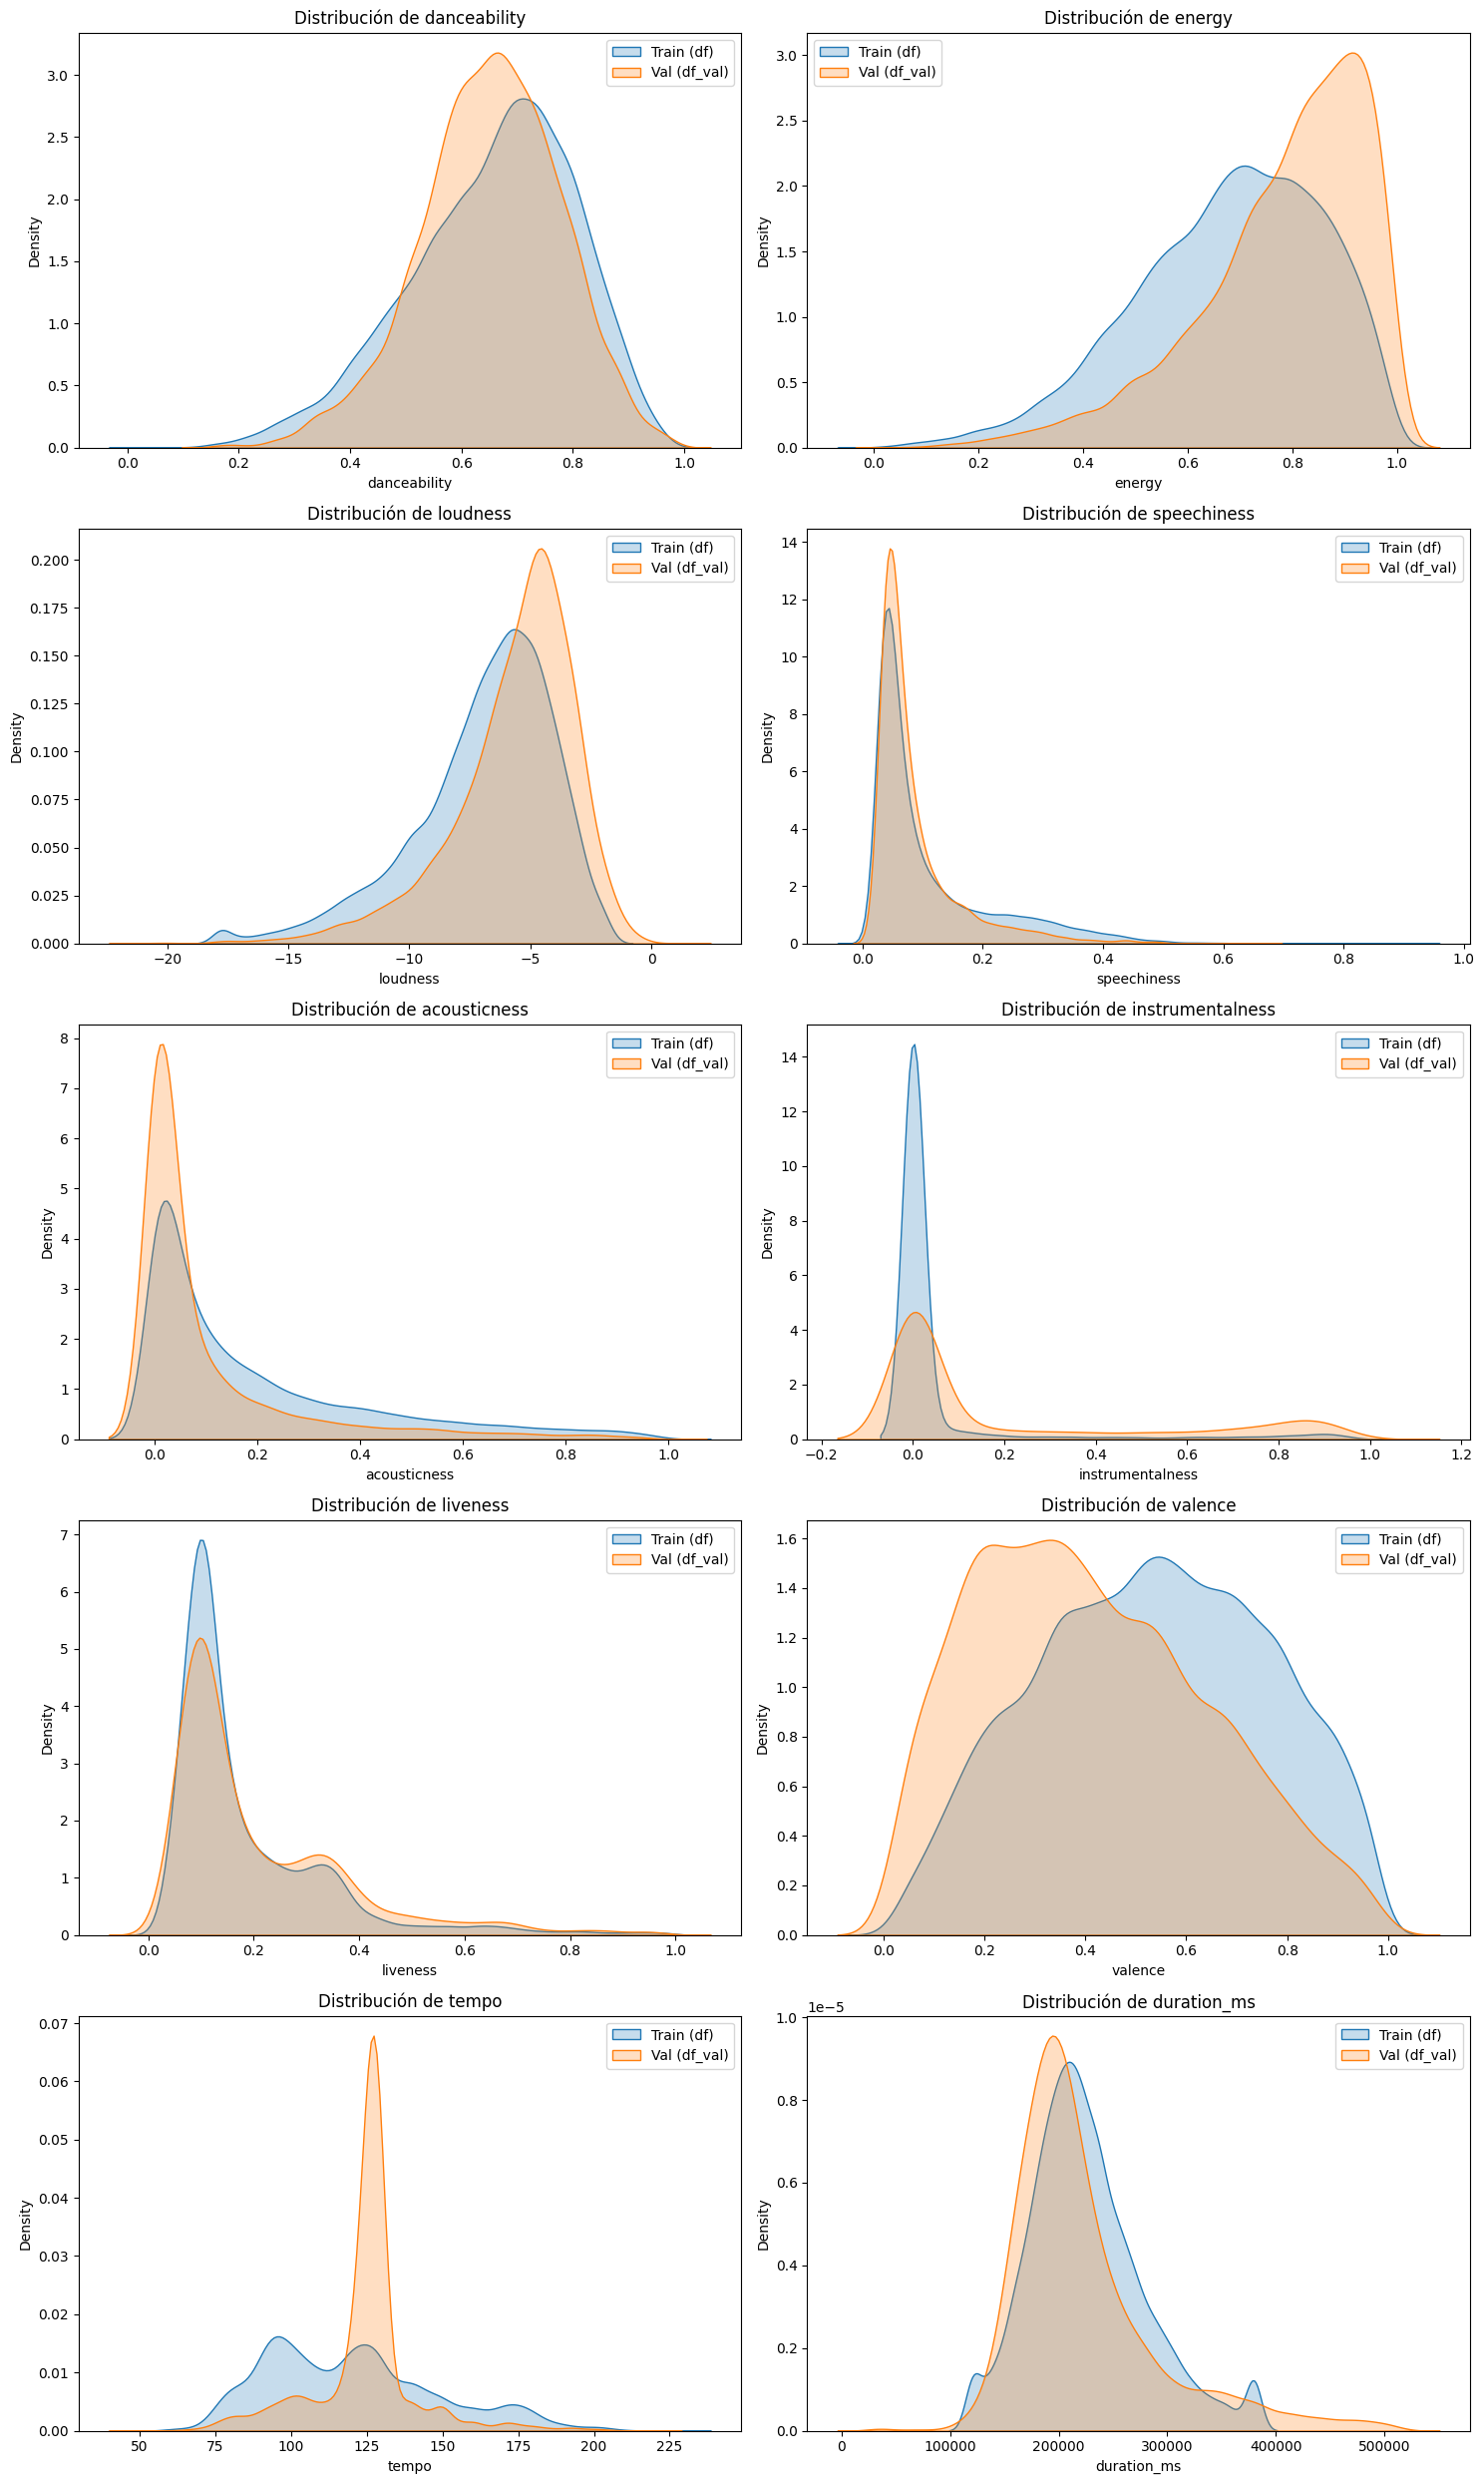

In [134]:
# Configuramos el tamaño de la figura según la cantidad de variables
n_cols = 2
n_rows = (len(numericas) + 1) // n_cols
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numericas):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(df[col], label='Train (df)', shade=True)
    sns.kdeplot(df_val[col], label='Val (df_val)', shade=True)
    plt.title(f'Distribución de {col}')
    plt.legend()

plt.tight_layout()
plt.show()

Mediante test de Kolmogorov verificamos que ninguna distribucion es identica entre train y validation

In [ ]:
from scipy.stats import ks_2samp

results = []
for col in numericas:
    stat, p_val = ks_2samp(df[col], df_val[col])
    results.append({
        'Variable': col,
        'KS Statistic': stat,
        'P-Value': p_val,
        'Identical Dist?': 'Yes' if p_val > 0.05 else 'No'
    })

df_ks = pd.DataFrame(results)
print("Prueba de Kolmogorov-Smirnov (Train vs Val):")
display(df_ks)

Prueba de Kolmogorov-Smirnov (Train vs Val):


,Variable,KS Statistic,P-Value,Identical Dist?
0,danceability,0.075747,1.155770e-26,No
1,energy,0.268970,0.000000e+00,No
2,loudness,0.217920,1.509194e-219,No
3,speechiness,0.100441,1.351122e-46,No
4,acousticness,0.265620,0.000000e+00,No
5,instrumentalness,0.280280,0.000000e+00,No
6,liveness,0.074217,1.296677e-25,No
7,valence,0.230216,2.782597e-245,No
8,tempo,0.317460,0.000000e+00,No
9,duration_ms,0.120155,1.482980e-66,No


In [133]:
# @title 📊 Comparación de Distribuciones: Train vs Validation {display-mode: "form"}
import pandas as pd
import json
from IPython.display import HTML
from google.colab import output

# Prepare data for the dashboard
numericas = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

def get_stats(df_set, name):
    stats_dict = {}
    for col in numericas:
        stats_dict[col] = {
            "mean": float(df_set[col].mean()),
            "std": float(df_set[col].std()),
            "count": int(df_set[col].count())
        }
    return stats_dict

# Generate histograms for JS
def get_hist_data(df_set, col, bins=20):
    counts, bin_edges = np.histogram(df_set[col].dropna(), bins=bins, density=True)
    return {"counts": counts.tolist(), "edges": bin_edges.tolist()}

data_payload = {
    "train_stats": get_stats(df, "Train"),
    "val_stats": get_stats(df_val, "Validation"),
    "columns": numericas,
    "plots": {
        col: {
            "train": get_hist_data(df, col),
            "val": get_hist_data(df_val, col)
        } for col in numericas
    }
}

def _report_js_error(message):
    print(f"JavaScript Error: {message}")

output.register_callback('report_js_error', _report_js_error)

html_content = """
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f4f6f8; margin: 0; padding: 20px; }
        .container { max-width: 1200px; margin: auto; }
        .header { display: flex; justify-content: space-between; align-items: center; margin-bottom: 20px; }
        .kpi-row { display: grid; grid-template-columns: repeat(auto-fit, minmax(250px, 1fr)); gap: 20px; margin-bottom: 20px; }
        .card { background: white; padding: 20px; border-radius: 12px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); }
        .kpi-card h3 { margin: 0; color: #666; font-size: 0.9rem; }
        .kpi-card p { margin: 10px 0 0; font-size: 1.8rem; font-weight: bold; color: #1a73e8; }
        .controls { margin-bottom: 20px; background: white; padding: 15px; border-radius: 12px; display: flex; align-items: center; gap: 15px; }
        select { padding: 8px 12px; border-radius: 6px; border: 1px solid #ddd; font-size: 1rem; cursor: pointer; }
        .main-chart-container { background: white; padding: 20px; border-radius: 12px; margin-bottom: 20px; height: 500px; display: flex; flex-direction: column; }
        .canvas-wrapper { position: relative; flex-grow: 1; min-height: 0; }
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h2>Análisis Comparativo de Distribuciones</h2>
        </div>

        <div class="kpi-row" id="kpiRow">
            <div class="card kpi-card"><h3>Registros Train</h3><p id="kpiTrain">0</p></div>
            <div class="card kpi-card"><h3>Registros Val</h3><p id="kpiVal">0</p></div>
            <div class="card kpi-card"><h3>Variable Seleccionada</h3><p id="kpiVar">-</p></div>
        </div>

        <div class="controls">
            <label for="varSelect">Seleccionar Variable:</label>
            <select id="varSelect"></select>
        </div>

        <div class="card main-chart-container">
            <h3>Comparación de Densidad (Histograma)</h3>
            <div class="canvas-wrapper">
                <canvas id="distChart"></canvas>
            </div>
        </div>
    </div>

    <script>
        window.onerror = function(message) { google.colab.kernel.invokeFunction('report_js_error', [message], {}); };

        const data = DATA_JSON_PLACEHOLDER;
        let chart = null;

        const select = document.getElementById('varSelect');
        data.columns.forEach(col => {
            const opt = document.createElement('option');
            opt.value = col;
            opt.textContent = col;
            select.appendChild(opt);
        });

        document.getElementById('kpiTrain').textContent = Object.values(data.train_stats)[0].count;
        document.getElementById('kpiVal').textContent = Object.values(data.val_stats)[0].count;

        function updateDashboard() {
            const col = select.value;
            document.getElementById('kpiVar').textContent = col;

            const plotData = data.plots[col];
            const ctx = document.getElementById('distChart').getContext('2d');

            if (chart) chart.destroy();

            chart = new Chart(ctx, {
                type: 'line',
                data: {
                    labels: plotData.train.edges.map(e => e.toFixed(2)),
                    datasets: [
                        {
                            label: 'Train (Density)',
                            data: plotData.train.counts,
                            borderColor: '#1a73e8',
                            backgroundColor: 'rgba(26, 115, 232, 0.2)',
                            fill: true,
                            tension: 0.4
                        },
                        {
                            label: 'Validation (Density)',
                            data: plotData.val.counts,
                            borderColor: '#d93025',
                            backgroundColor: 'rgba(217, 48, 37, 0.2)',
                            fill: true,
                            tension: 0.4
                        }
                    ]
                },
                options: {
                    responsive: true,
                    maintainAspectRatio: false,
                    scales: {
                        y: { beginAtZero: true, title: { display: true, text: 'Densidad' } },
                        x: { title: { display: true, text: 'Valor' } }
                    }
                }
            });
        }

        select.addEventListener('change', updateDashboard);
        updateDashboard();
    </script>
</body>
</html>
""".replace('DATA_JSON_PLACEHOLDER', json.dumps(data_payload))

display(HTML(html_content))

### Comparamos playlist_genre

In [158]:
genres_df = set(df['playlist_genre'].unique())
genres_val = set(df_val['playlist_genre'].unique())

# Calculamos las diferencias y la intersección
solo_en_df = genres_df - genres_val
solo_en_df_val = genres_val - genres_df
en_ambos = genres_df & genres_val

# Creamos una tabla comparativa
# Ajustamos las longitudes para poder crear el DataFrame
max_len = max(len(solo_en_df), len(solo_en_df_val), len(en_ambos))

comparativa = pd.DataFrame({
    'Solo en Train (df)': list(solo_en_df) + [None] * (max_len - len(solo_en_df)),
    'Solo en Val (df_val)': list(solo_en_df_val) + [None] * (max_len - len(solo_en_df_val)),
    'En Ambos': list(en_ambos) + [None] * (max_len - len(en_ambos))
})

display(comparativa)

,Solo en Train (df),Solo en Val (df_val),En Ambos
0,latin,edm,r&b
1,pop,None,None
2,rock,None,None
3,rap,None,None


In [161]:
pd.concat([df['playlist_genre'].value_counts(), df['playlist_genre'].value_counts(normalize=True)], axis=1)

,count,proportion
playlist_genre,,
rap,5746,0.218762
pop,5507,0.209663
latin,5155,0.196261
rock,4951,0.188495
r&b,4907,0.186819


In [162]:
pd.concat([df_val['playlist_genre'].value_counts(), df_val['playlist_genre'].value_counts(normalize=True)], axis=1)

,count,proportion
playlist_genre,,
edm,6043,0.920207
r&b,524,0.079793


Comparamos las distribuciones de las variables entre todos los generos de playlist_genre

--> Aca vemos las verdaderas diferencias: no es que el dataset de Train y Val son solo distintos, sino que son distintos porque Val tiene mayoritariamente el genero **edm** que tiene otra distribucion

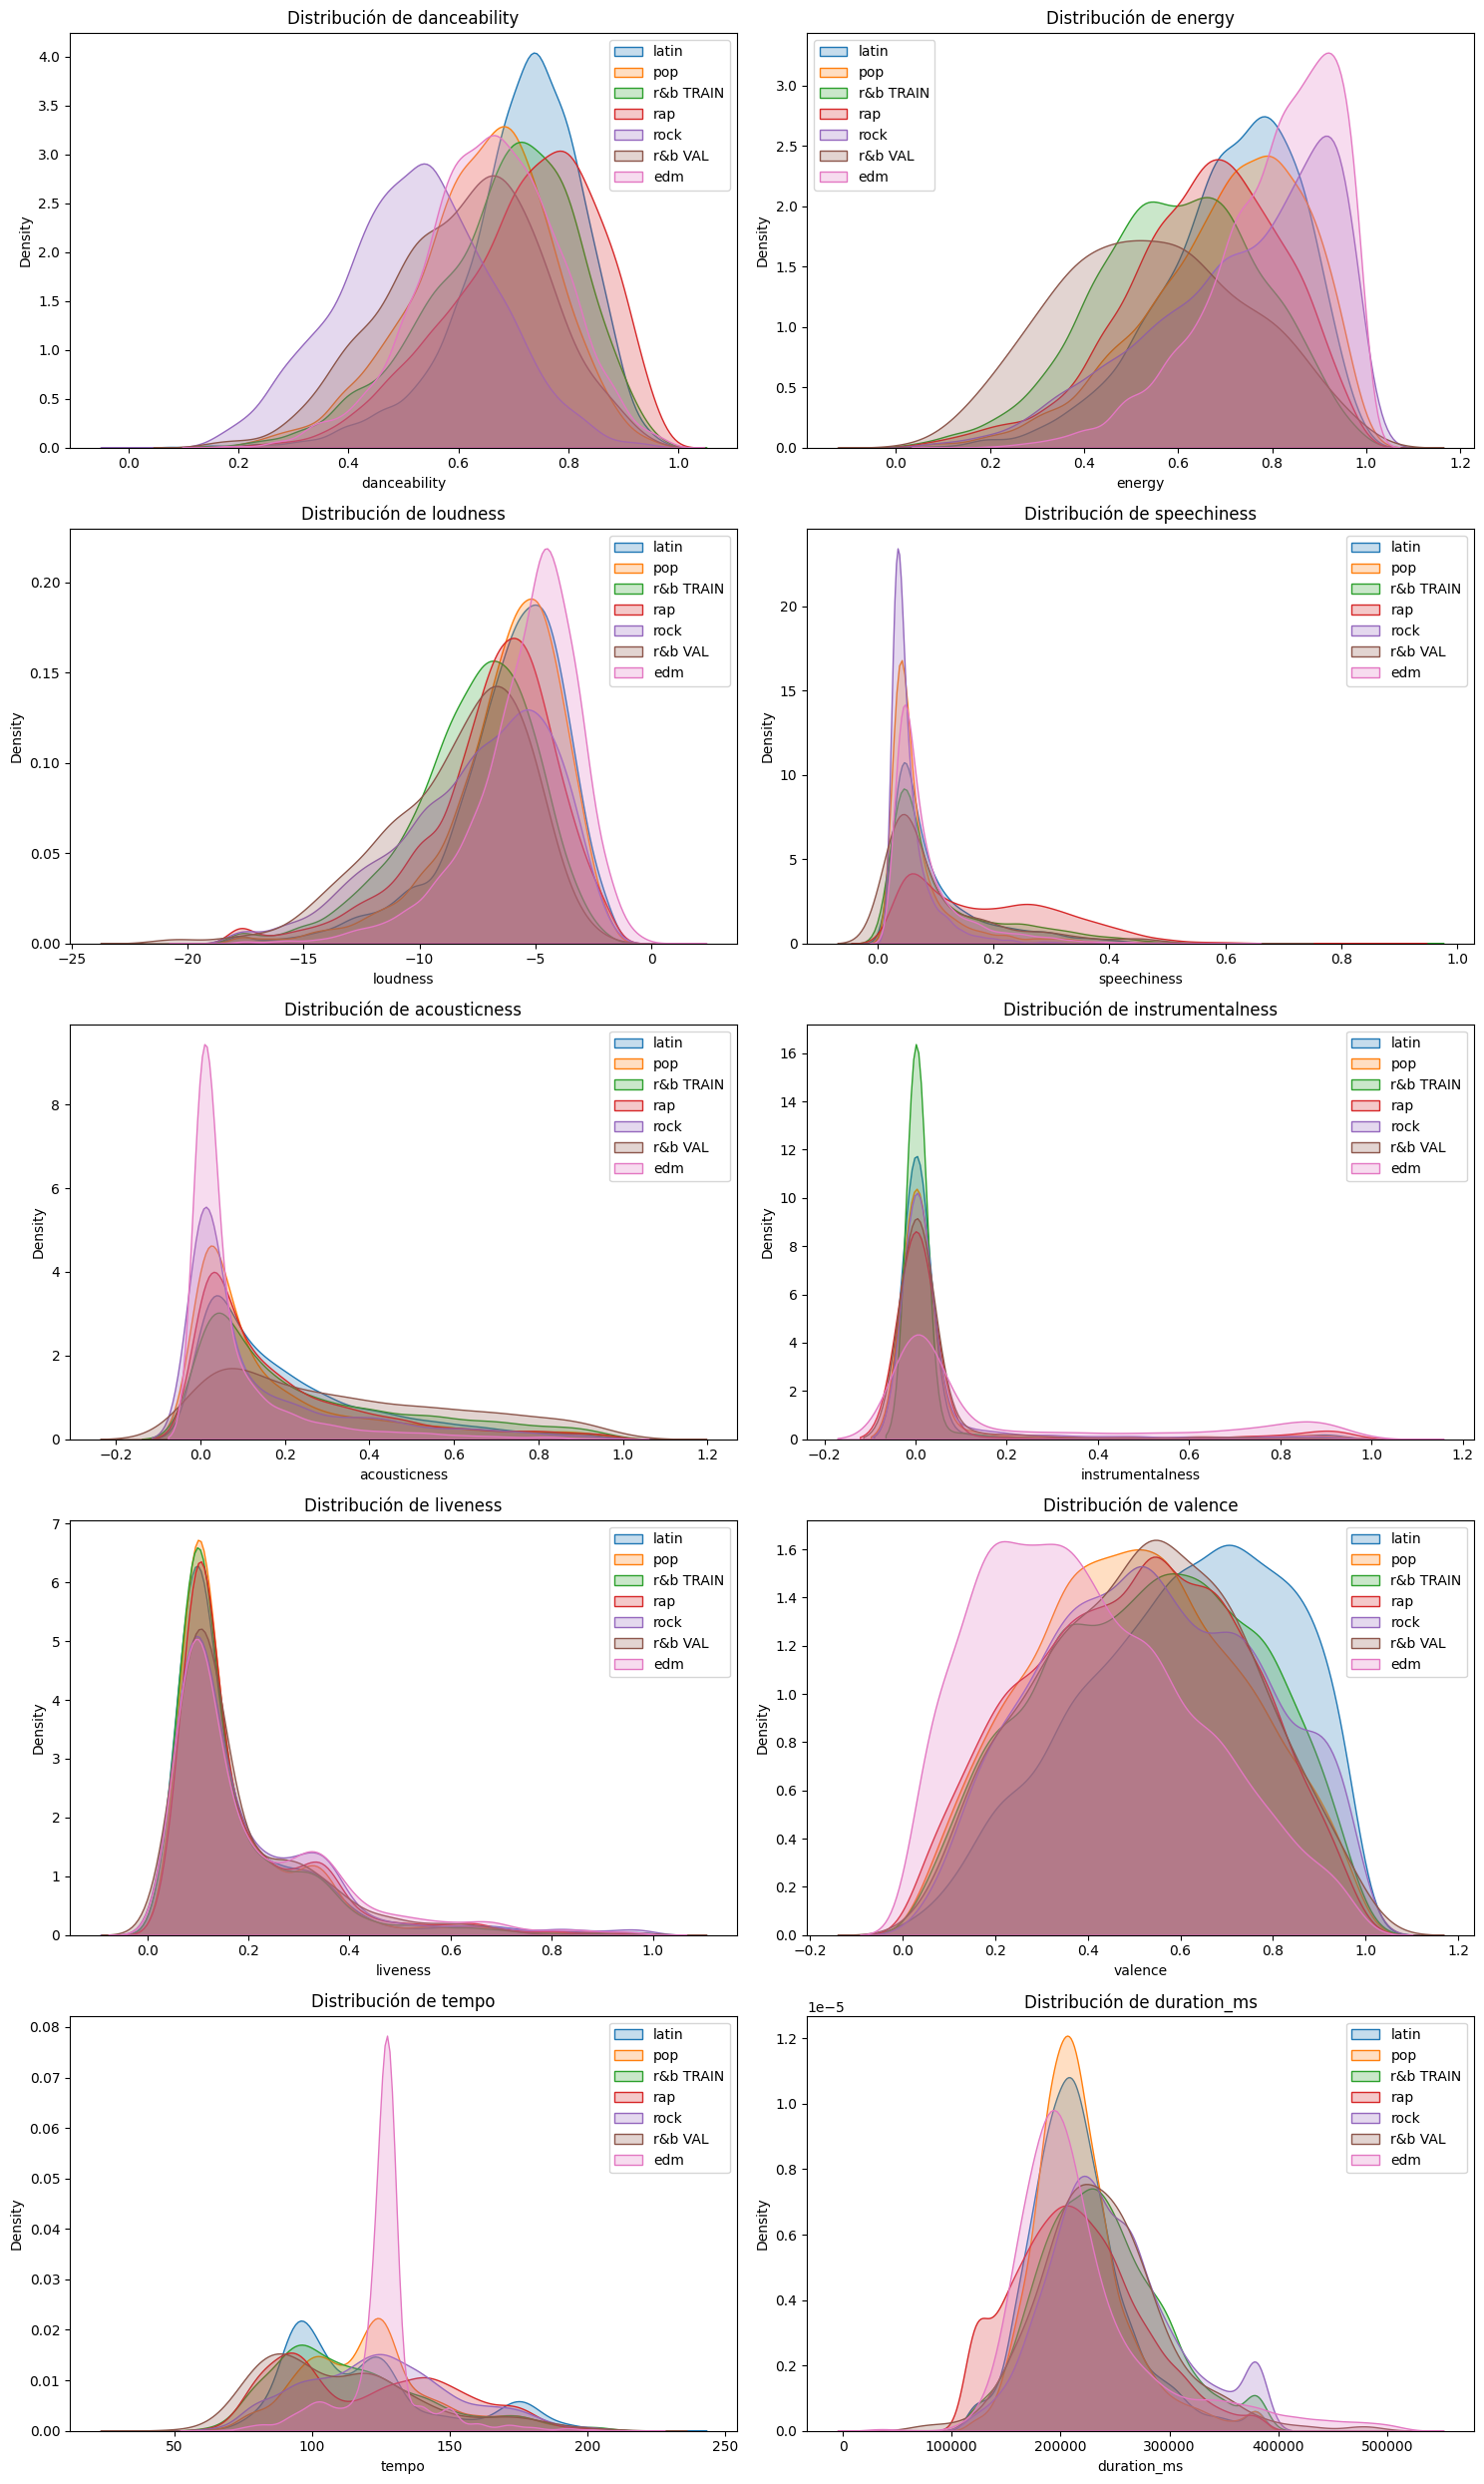

In [164]:
# Configuramos el tamaño de la figura según la cantidad de variables
n_cols = 2
n_rows = (len(numericas) + 1) // n_cols
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numericas):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(df.loc[df['playlist_genre'] == 'latin',col], label='latin', shade=True)
    sns.kdeplot(df.loc[df['playlist_genre'] == 'pop',col], label='pop', shade=True)
    sns.kdeplot(df.loc[df['playlist_genre'] == 'r&b',col], label='r&b TRAIN', shade=True)
    sns.kdeplot(df.loc[df['playlist_genre'] == 'rap',col], label='rap', shade=True)
    sns.kdeplot(df.loc[df['playlist_genre'] == 'rock',col], label='rock', shade=True)
    sns.kdeplot(df_val.loc[df_val['playlist_genre'] == 'r&b',col], label='r&b VAL', shade=True)
    sns.kdeplot(df_val.loc[df_val['playlist_genre'] == 'edm',col], label='edm', shade=True)
    plt.title(f'Distribución de {col}')
    plt.legend()

plt.tight_layout()
plt.show()

In [172]:
subgenres_df = set(df['playlist_subgenre'].unique())
subgenres_val = set(df_val['playlist_subgenre'].unique())

# Calculamos las diferencias y la intersección
solo_en_df = subgenres_df - subgenres_val
solo_en_df_val = subgenres_val - subgenres_df
en_ambos = subgenres_df & subgenres_val

# Creamos una tabla comparativa
# Ajustamos las longitudes para poder crear el DataFrame
max_len = max(len(solo_en_df), len(solo_en_df_val), len(en_ambos))

comparativa = pd.DataFrame({
    'Solo en Train (df)': list(solo_en_df) + [None] * (max_len - len(solo_en_df)),
    'Solo en Val (df_val)': list(solo_en_df_val) + [None] * (max_len - len(solo_en_df_val)),
    'En Ambos': list(en_ambos) + [None] * (max_len - len(en_ambos))
})

display(comparativa)

,Solo en Train (df),Solo en Val (df_val),En Ambos
0,permanent wave,big room,neo soul
1,classic rock,electro house,None
2,album rock,progressive electro house,None
3,trap,pop edm,None
4,southern hip hop,None,None
5,reggaeton,None,None
6,hip hop,None,None
7,latin hip hop,None,None
8,urban contemporary,None,None
9,new jack swing,None,None


El neosoul debe pertenecer a r&b

In [173]:
pd.concat([df_val['playlist_subgenre'].value_counts(), df_val['playlist_subgenre'].value_counts(normalize=True)], axis=1)

,count,proportion
playlist_subgenre,,
progressive electro house,1809,0.275468
pop edm,1517,0.231004
electro house,1511,0.230090
big room,1206,0.183646
neo soul,524,0.079793


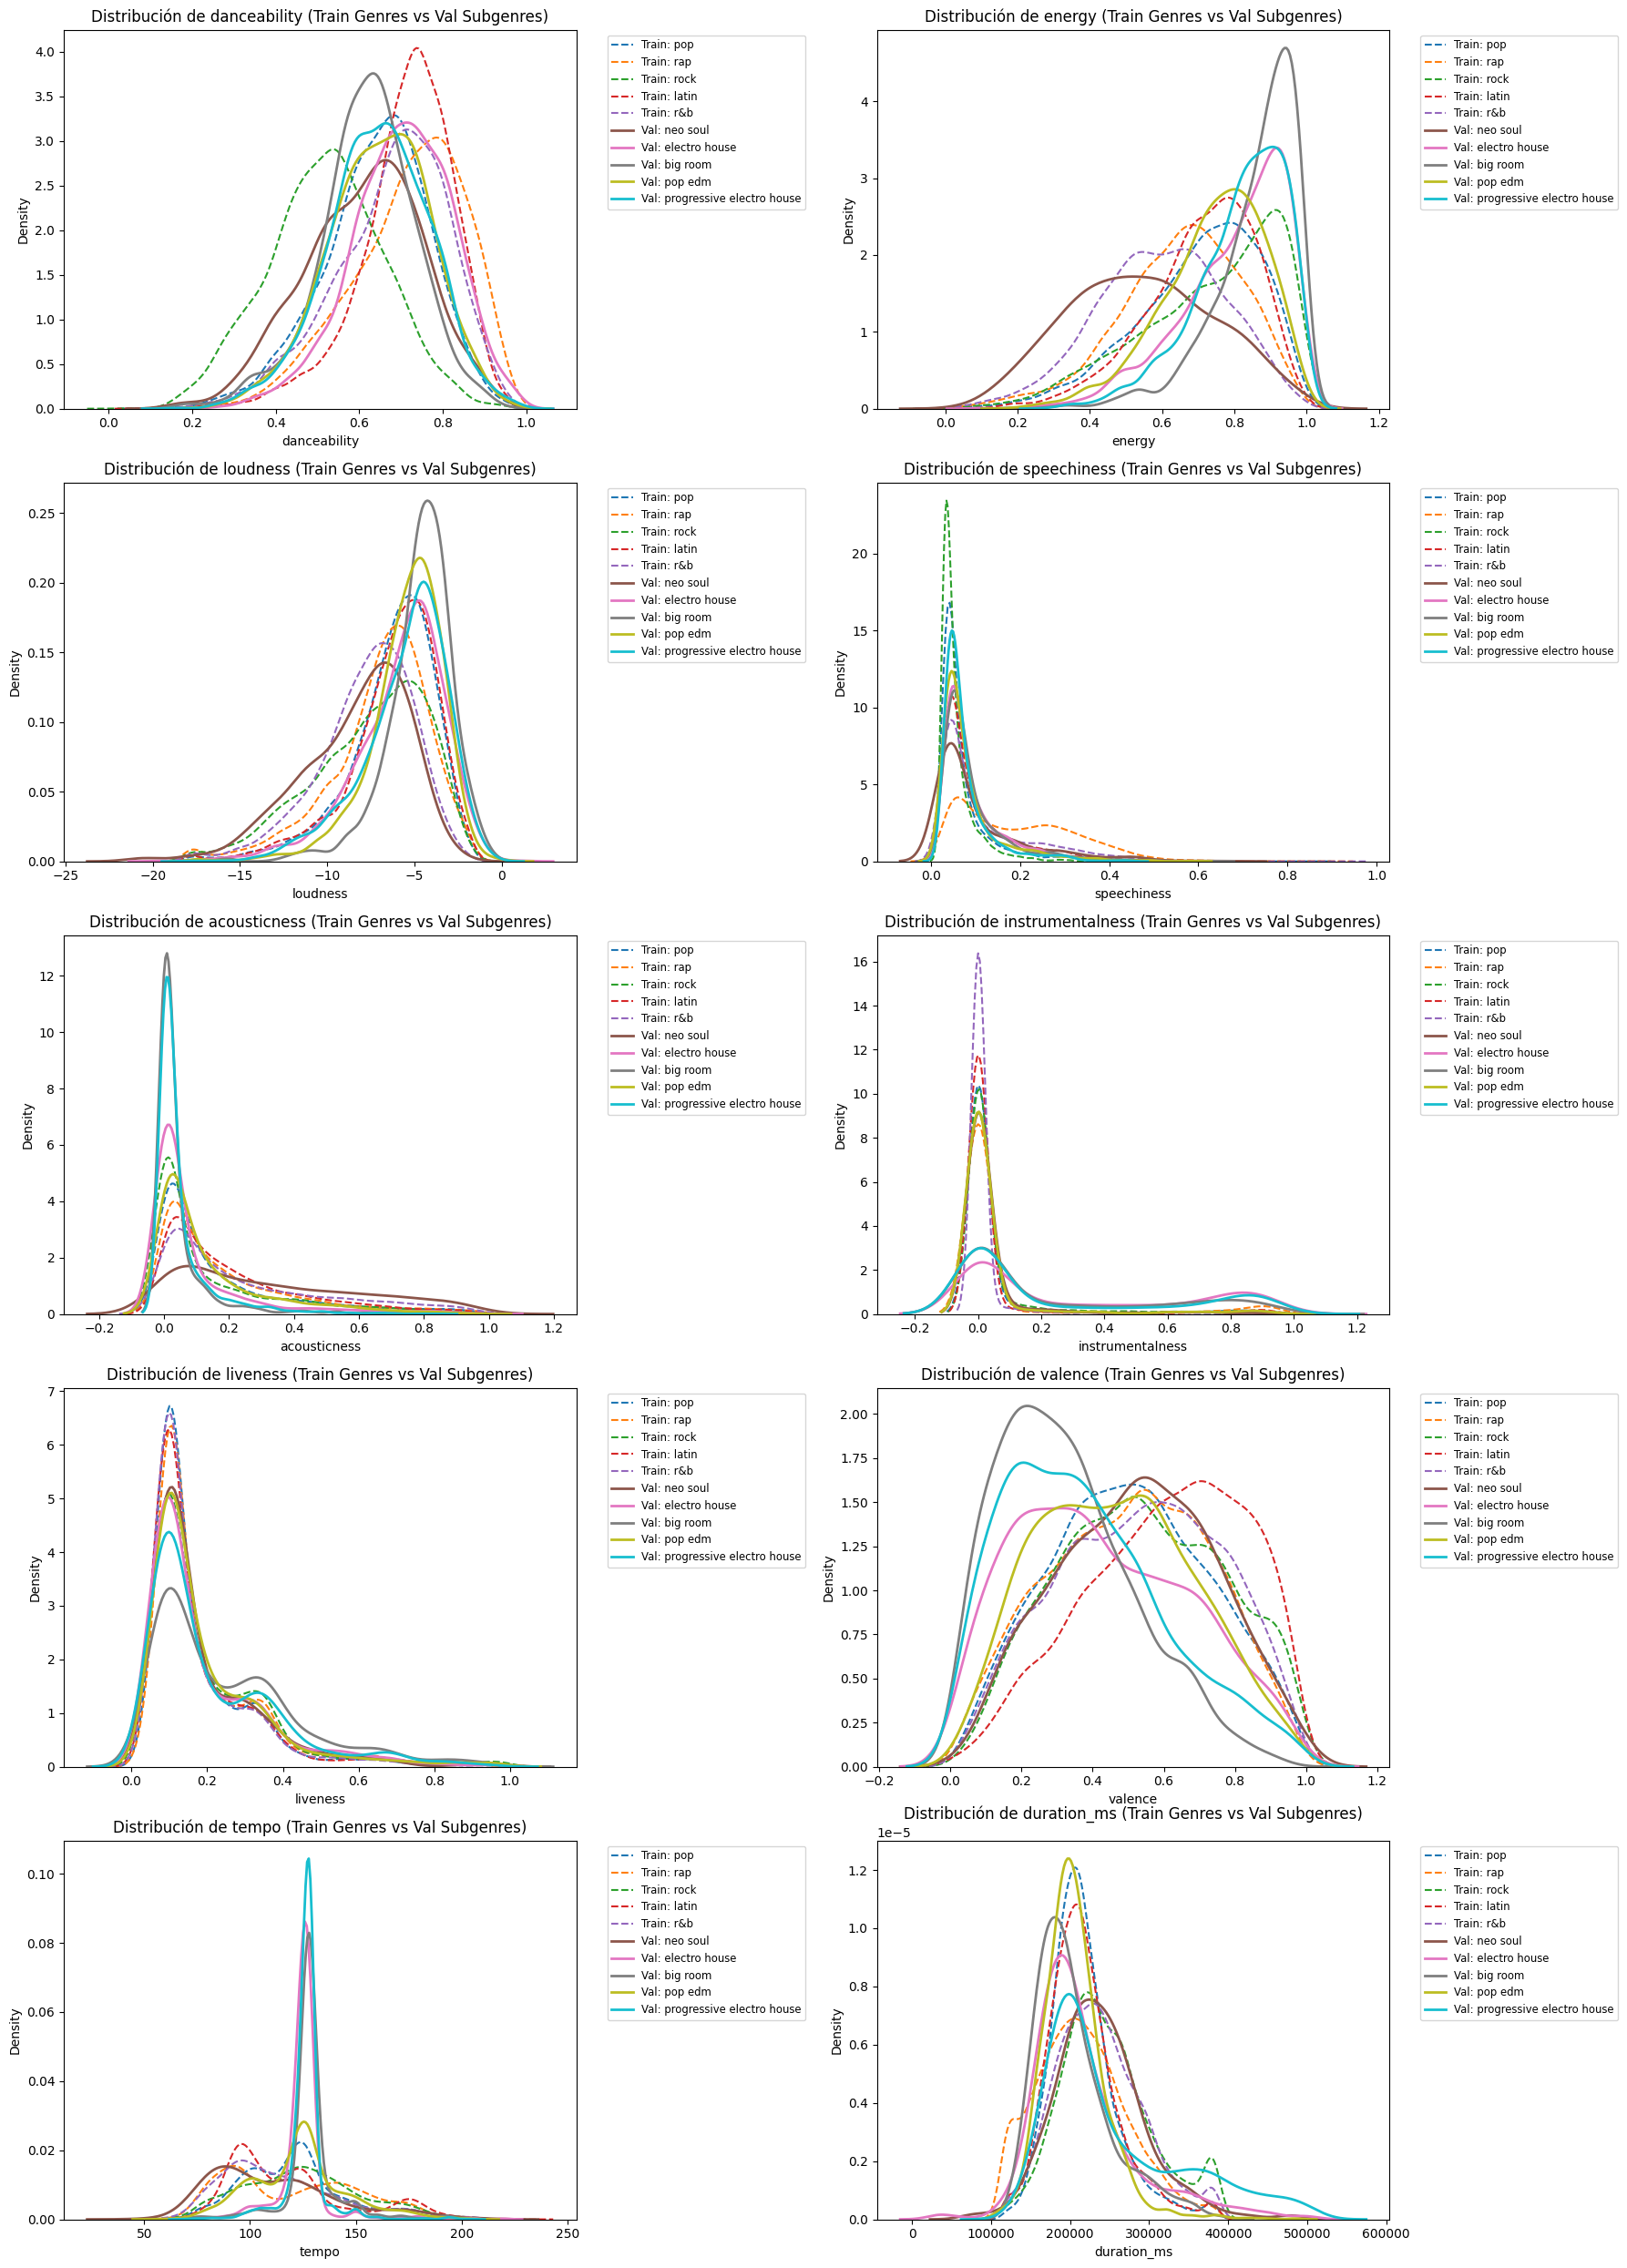

In [174]:
# Comparison of numerical distributions: Train Genres vs Val Subgenres
n_cols = 2
n_rows = (len(numericas) + 1) // n_cols
plt.figure(figsize=(18, 5 * n_rows))

genres_train = df['playlist_genre'].unique()
subgenres_val = df_val['playlist_subgenre'].unique()

for i, col in enumerate(numericas):
    plt.subplot(n_rows, n_cols, i + 1)

    # Plot Train Genres
    for g in genres_train:
        sns.kdeplot(df.loc[df['playlist_genre'] == g, col], label=f'Train: {g}', linestyle='--')

    # Plot Val Subgenres
    for sg in subgenres_val:
        sns.kdeplot(df_val.loc[df_val['playlist_subgenre'] == sg, col], label=f'Val: {sg}', linewidth=2)

    plt.title(f'Distribución de {col} (Train Genres vs Val Subgenres)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

### Comparamos mode y key

Difiere en un 6% el porcentaje de cada tipo de mode

In [176]:
comparativa_anios = pd.DataFrame({
    'Prop_Train': df['mode'].value_counts(normalize=True),
    'Prop_Val': df_val['mode'].value_counts(normalize=True)
}).sort_index()

comparativa_anios['diferencia'] = comparativa_anios['Prop_Train'] - comparativa_anios['Prop_Val']
display(comparativa_anios)

,Prop_Train,Prop_Val,diferencia
mode,,,
0,0.422028,0.483326,-0.061297
1,0.577972,0.516674,0.061297


Vemos que la mode es totalmente irrelevante

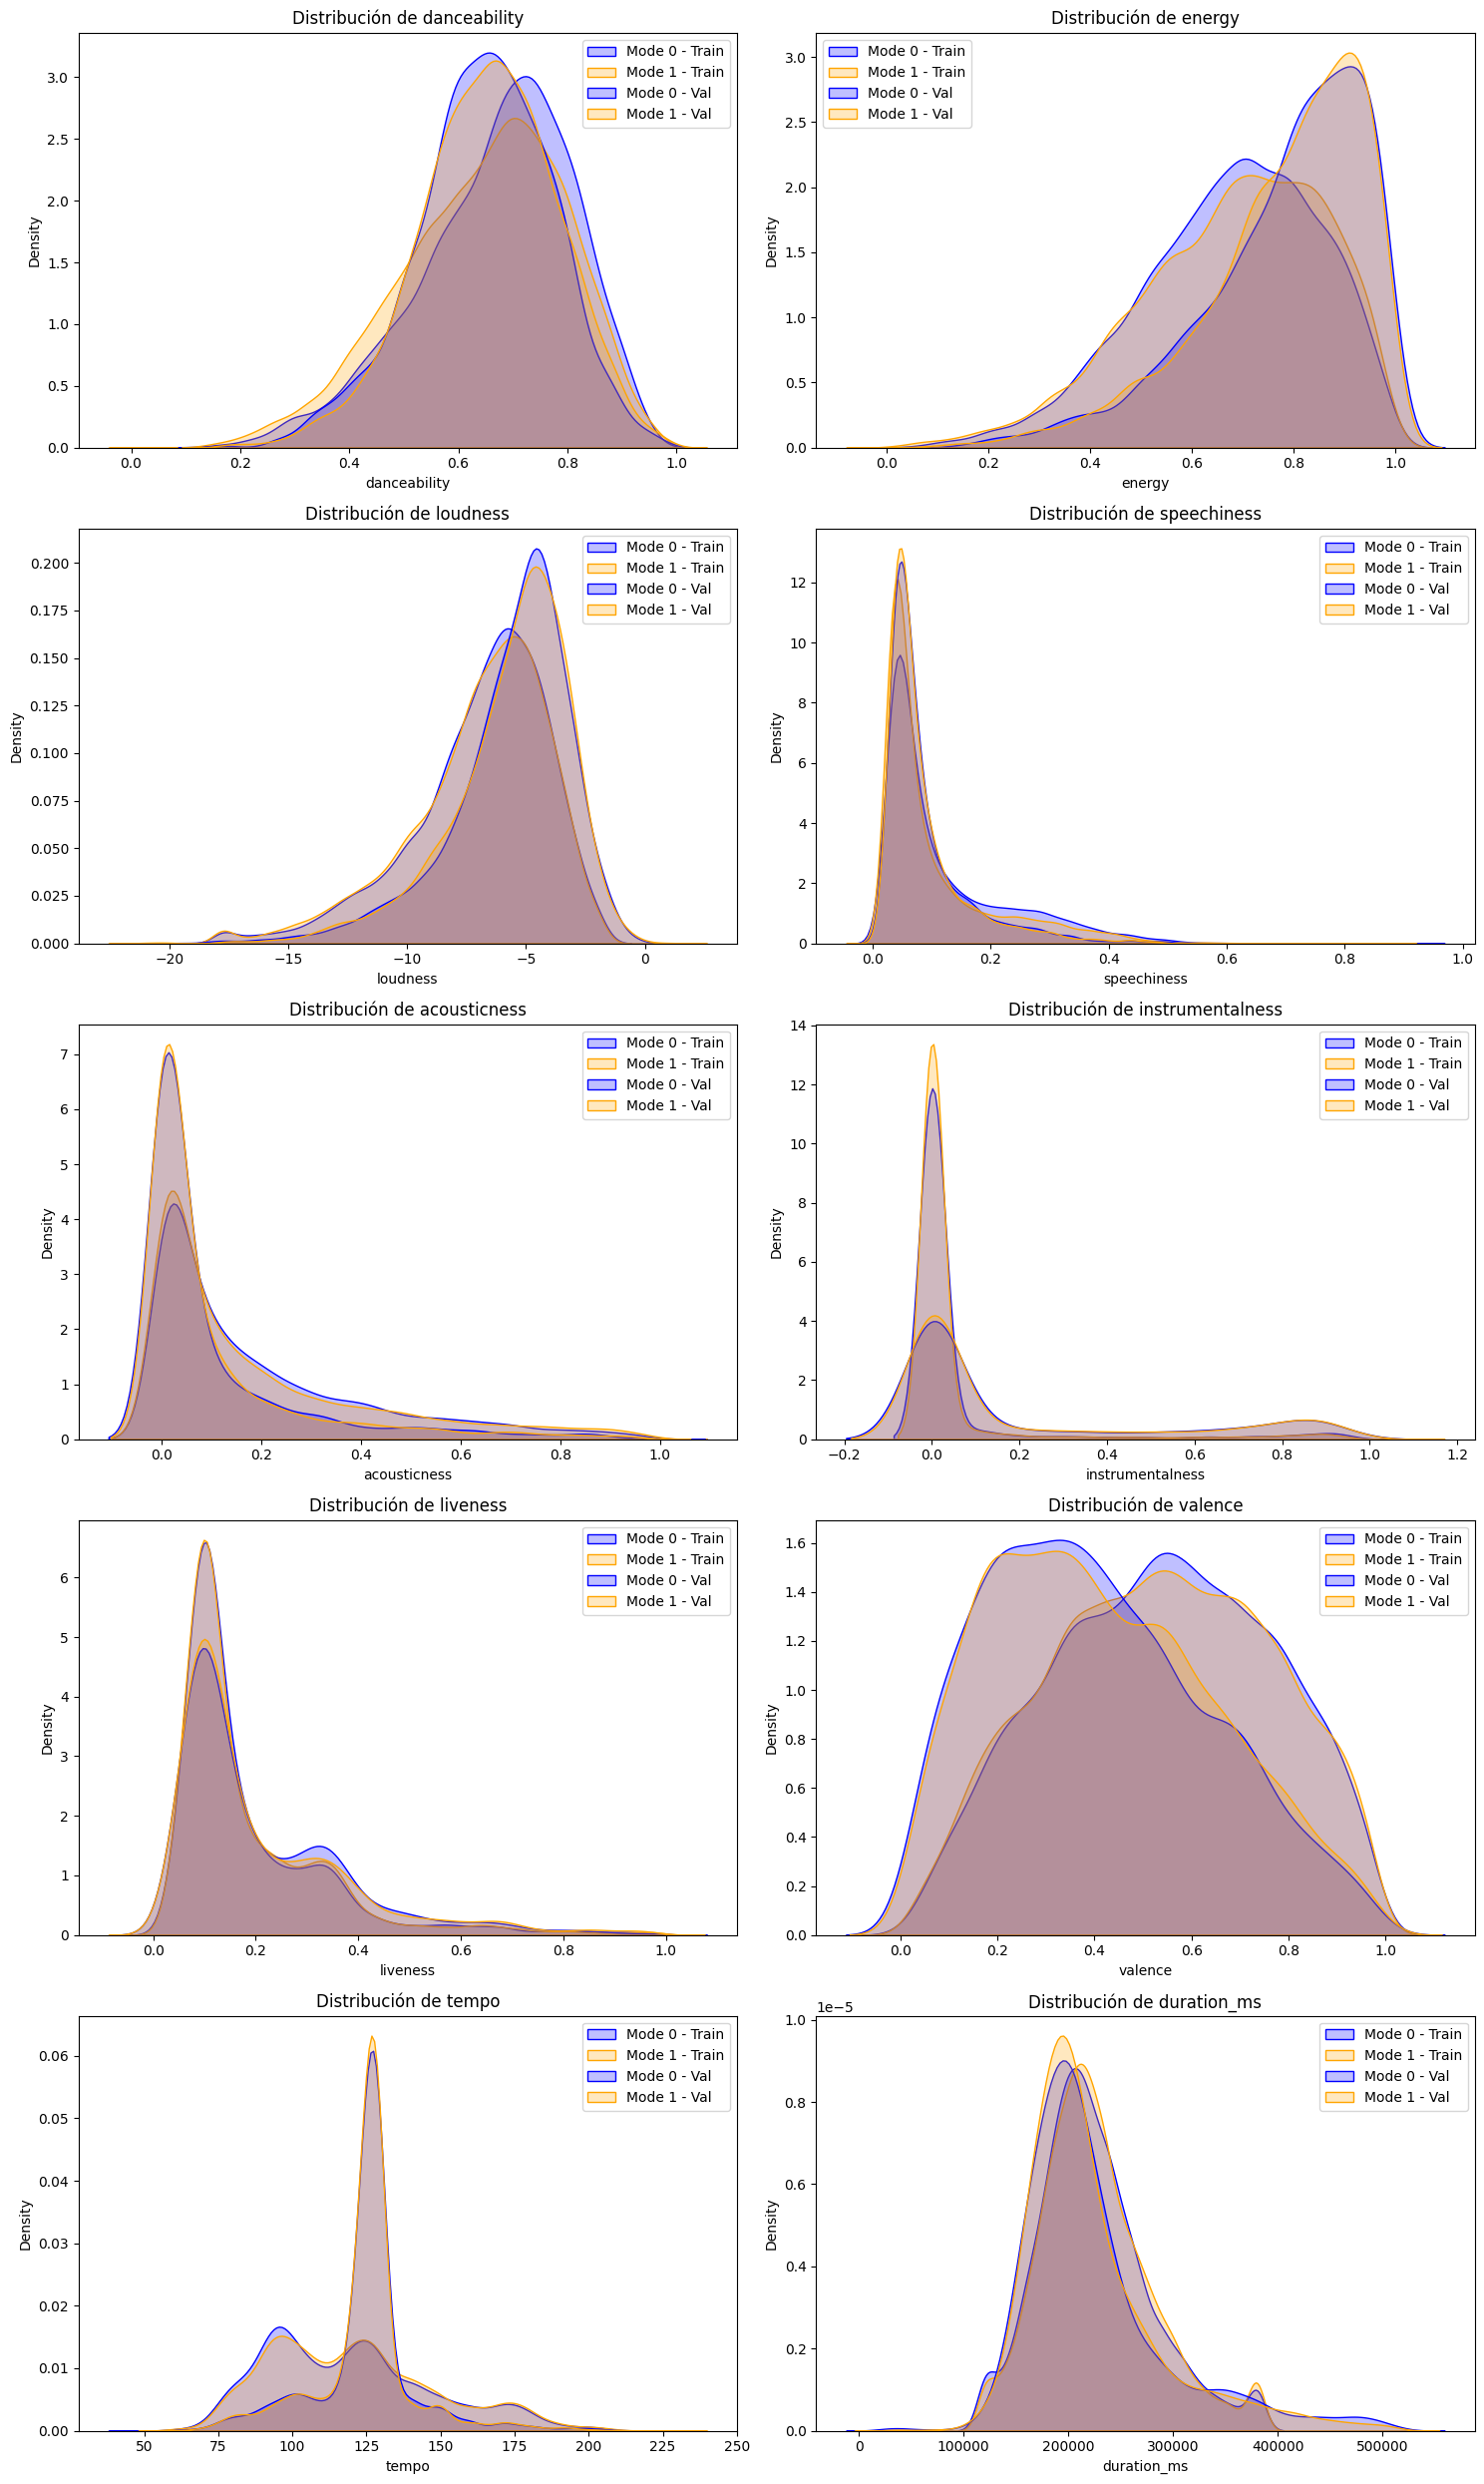

In [180]:
# Configuramos el tamaño de la figura según la cantidad de variables
n_cols = 2
n_rows = (len(numericas) + 1) // n_cols
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numericas):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(df.loc[df['mode'] == 0,col], label='Mode 0 - Train', shade=True, color='blue')
    sns.kdeplot(df.loc[df['mode'] == 1,col], label='Mode 1 - Train', shade=True, color='orange')
    sns.kdeplot(df_val.loc[df['mode'] == 0,col], label='Mode 0 - Val', shade=True, color='blue')
    sns.kdeplot(df_val.loc[df['mode'] == 1,col], label='Mode 1 - Val', shade=True, color='orange')
    plt.title(f'Distribución de {col}')
    plt.legend()

plt.tight_layout()
plt.show()

Los porcentajes de cada key son muy muy parecidos

In [177]:
comparativa_anios = pd.DataFrame({
    'Prop_Train': df['key'].value_counts(normalize=True),
    'Prop_Val': df_val['key'].value_counts(normalize=True)
}).sort_index()

comparativa_anios['diferencia'] = comparativa_anios['Prop_Train'] - comparativa_anios['Prop_Val']
display(comparativa_anios)

,Prop_Train,Prop_Val,diferencia
key,,,
0,0.107287,0.096848,0.010439
1,0.121907,0.123039,-0.001133
2,0.086918,0.082838,0.004080
3,0.026650,0.032435,-0.005784
4,0.067882,0.063652,0.004231
5,0.077477,0.098218,-0.020742
6,0.078999,0.090605,-0.011605
7,0.101995,0.102482,-0.000487
8,0.073441,0.076291,-0.002850


Vemos que ya en el train que las keys no afectan a los otros parametros

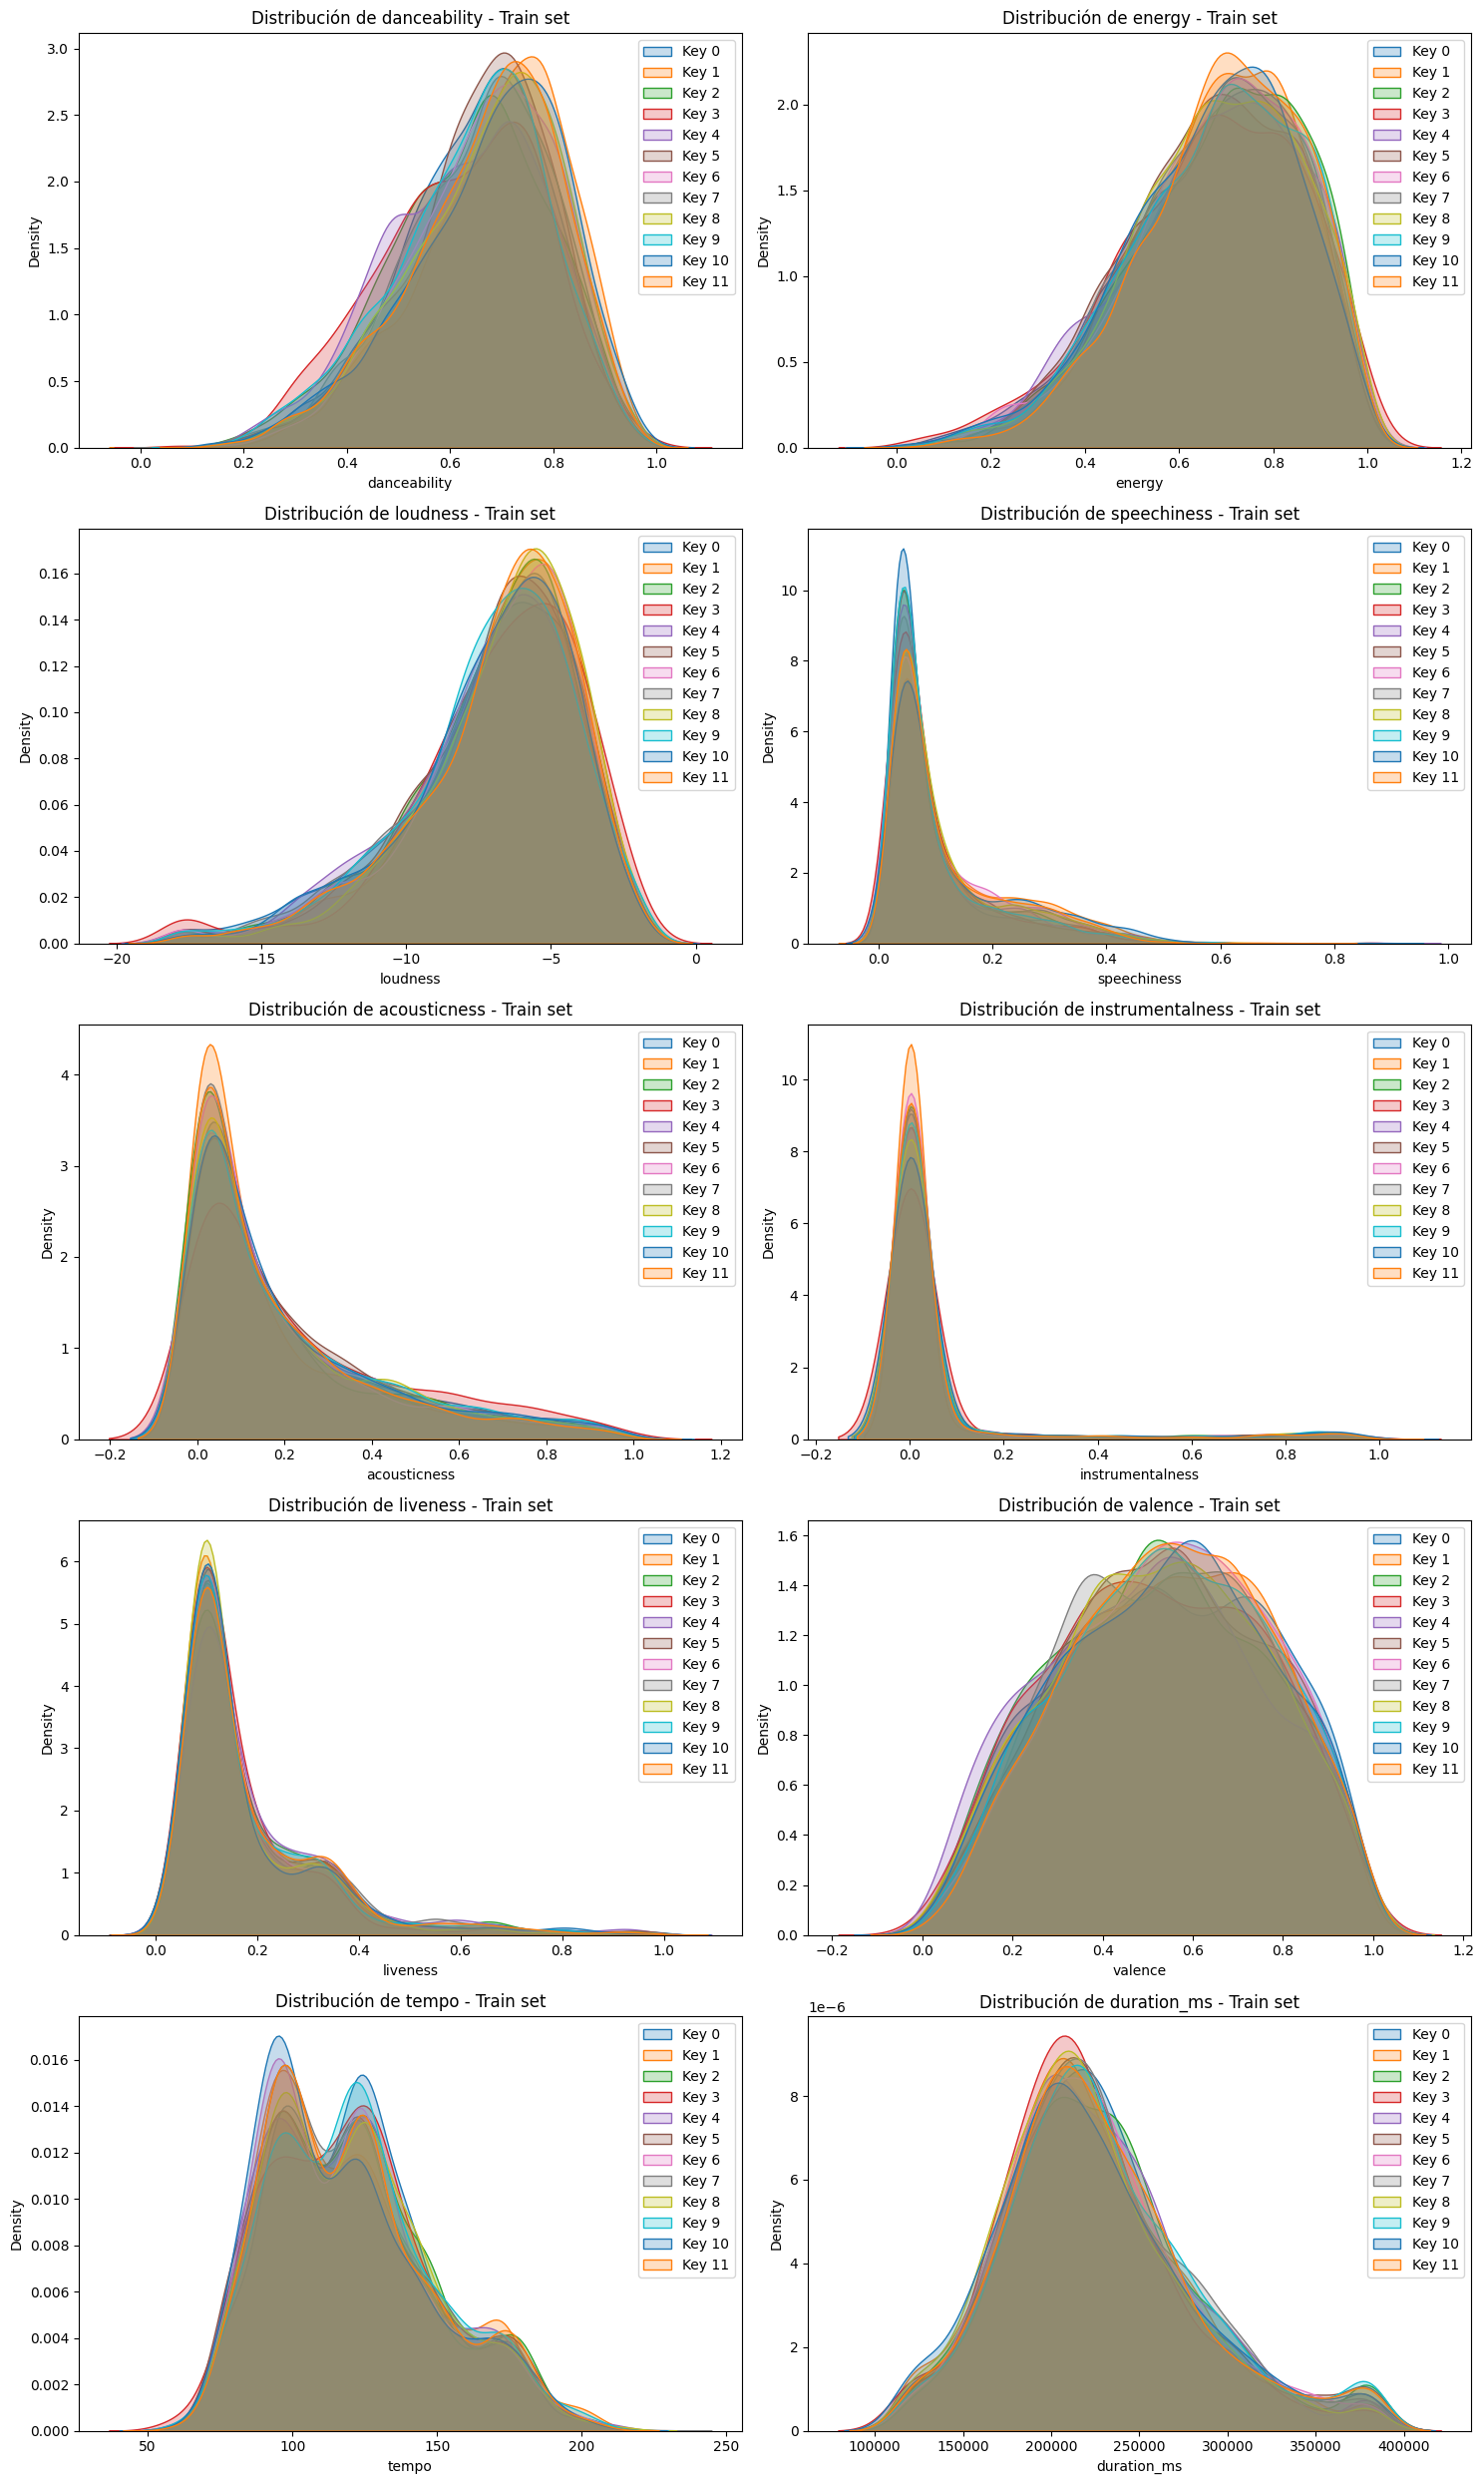

In [181]:
# Configuramos el tamaño de la figura según la cantidad de variables
n_cols = 2
n_rows = (len(numericas) + 1) // n_cols
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numericas):
    plt.subplot(n_rows, n_cols, i + 1)
    for k in range(12):
        sns.kdeplot(df.loc[df['key'] == k,col], label=f'Key {k}', shade=True)
    plt.title(f'Distribución de {col} - Train set')
    plt.legend()

plt.tight_layout()
plt.show()

### Outliers numericas

Variable danceability tiene un p-valor de normalidad de 7.75420559593418e-24


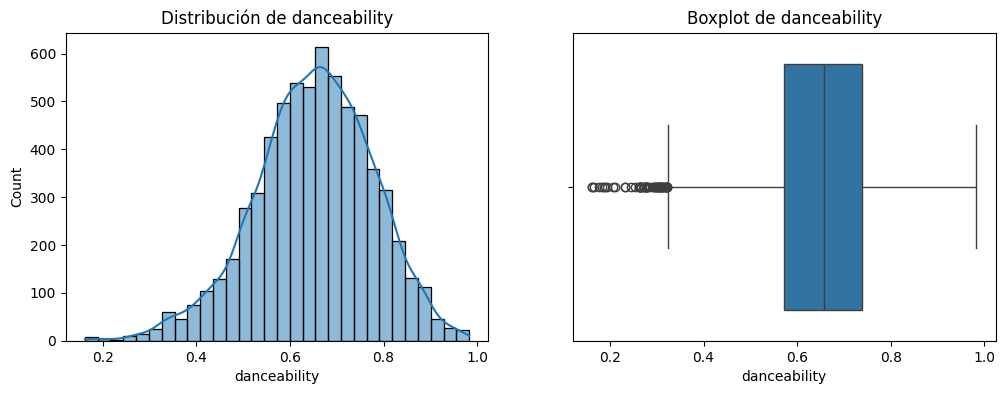

Variable energy tiene un p-valor de normalidad de 6.488738473192173e-232


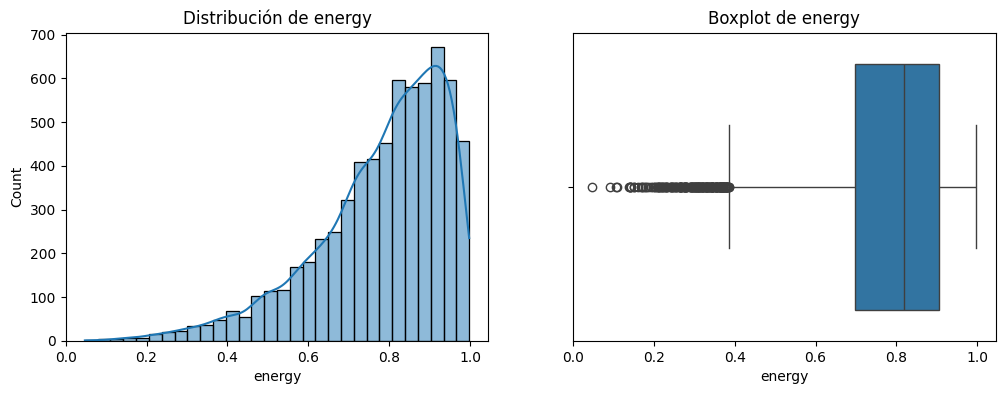

Variable loudness tiene un p-valor de normalidad de 0.0


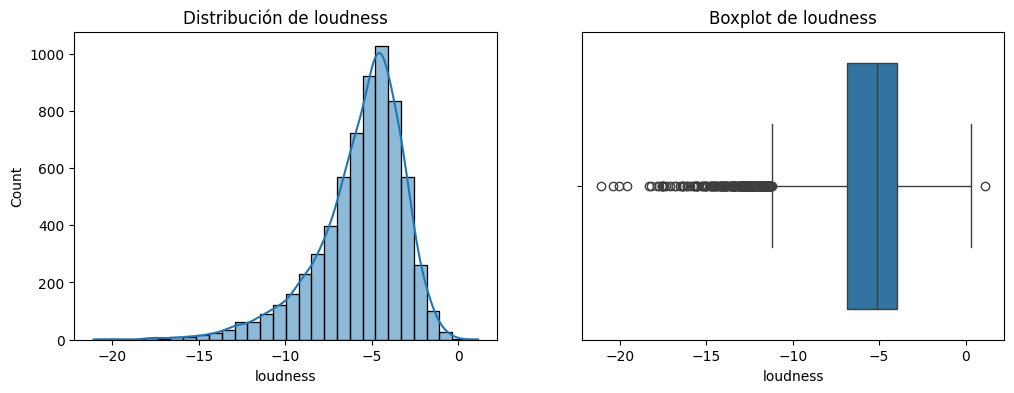

Variable speechiness tiene un p-valor de normalidad de 0.0


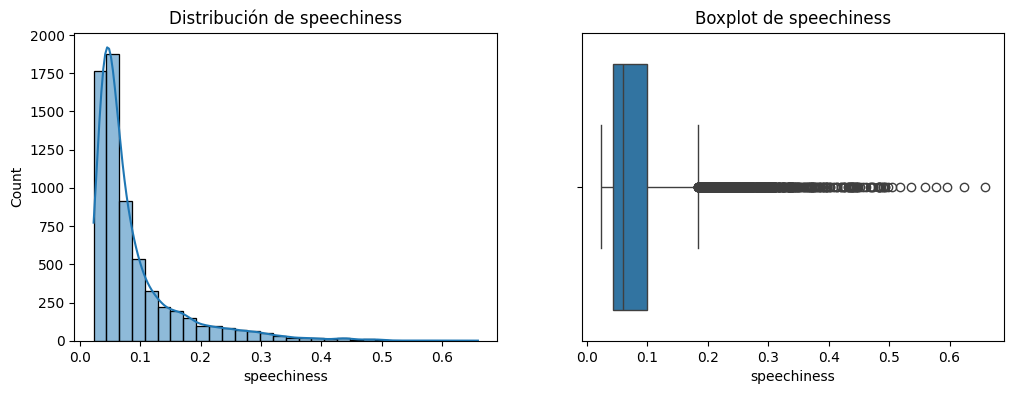

Variable acousticness tiene un p-valor de normalidad de 0.0


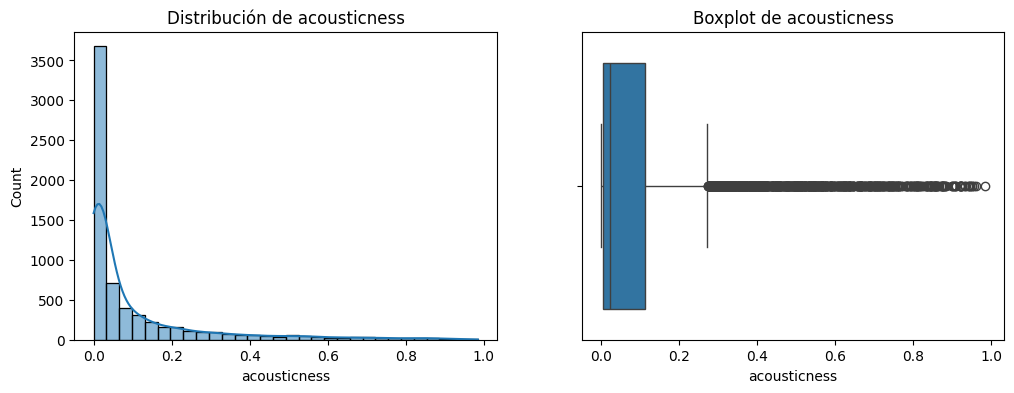

Variable instrumentalness tiene un p-valor de normalidad de 1.0002750608224209e-235


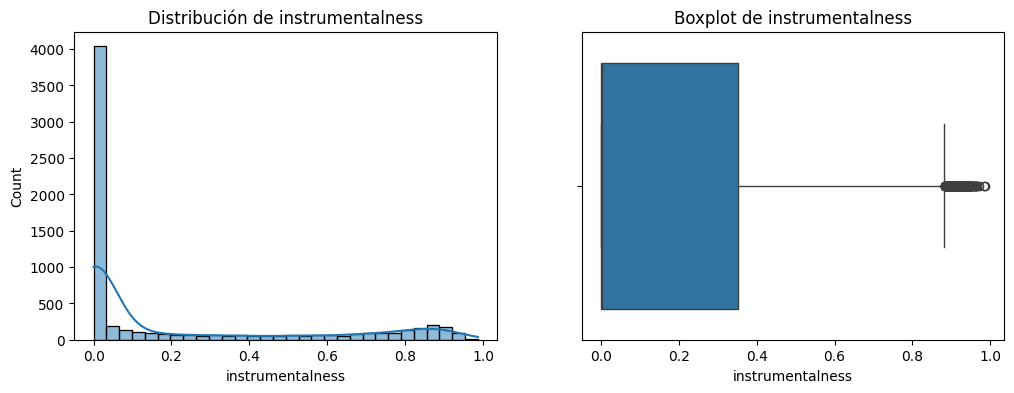

Variable liveness tiene un p-valor de normalidad de 0.0


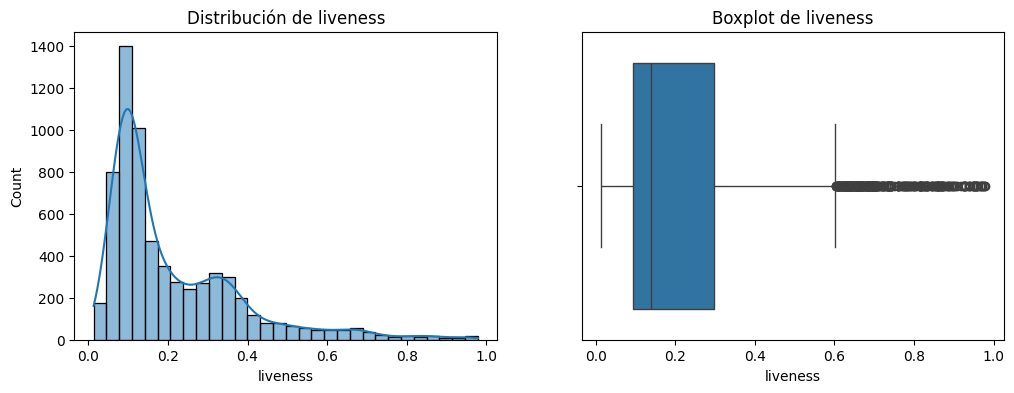

Variable valence tiene un p-valor de normalidad de 5.766302761934537e-103


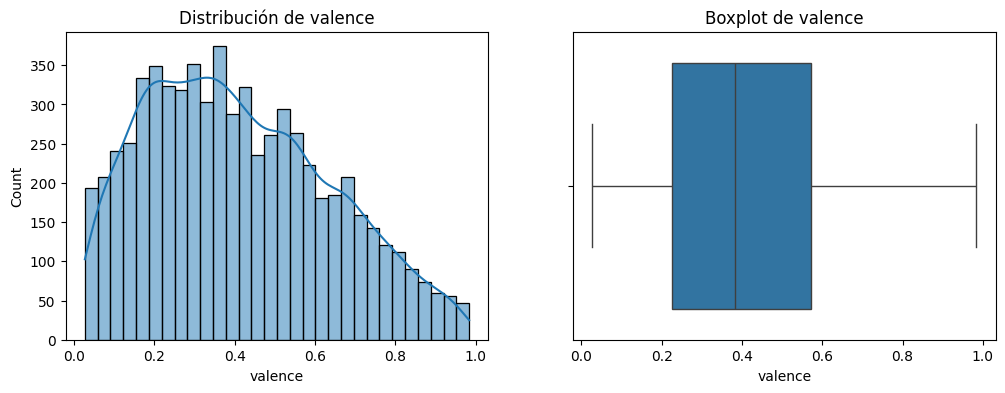

Variable tempo tiene un p-valor de normalidad de 8.938660737243632e-145


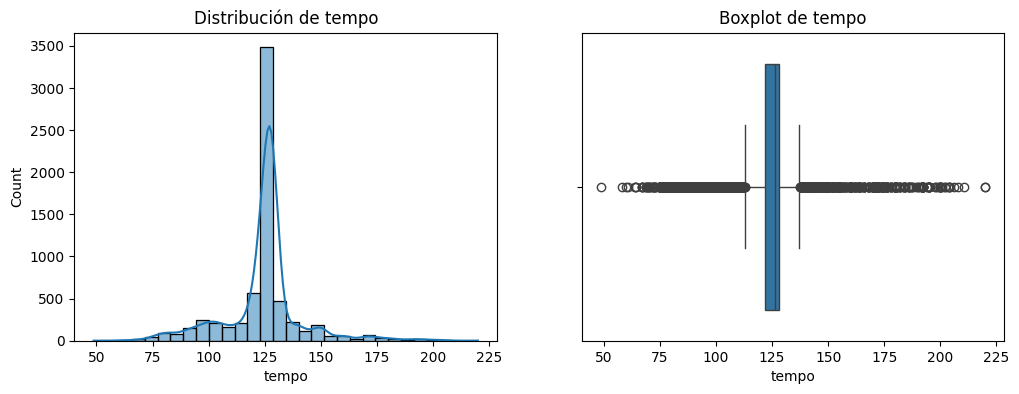

Variable duration_ms tiene un p-valor de normalidad de 0.0


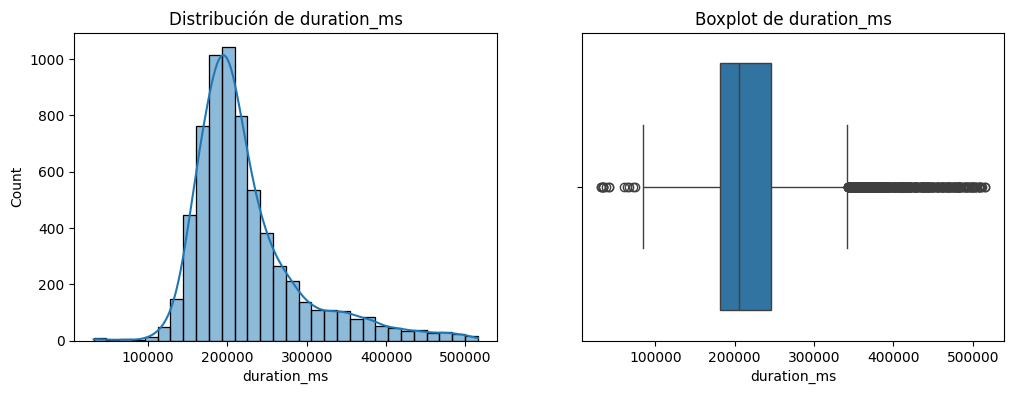

In [130]:
primer_paso_outliers(df_val, numericas)

En base TRAIN teniamos:

Variables con outliers en la distribución transformada:
- Danceability: 1
- Loudness: 275
- Instrumentalness: 5582
- Tempo: 15
- Duration ms: 827

Vars sin outliers fueron 5

Outliers **severos** en la distribución transformada:

- Loudness: 13
- Instrumentalness: 5048
- Tempo: 1
- Duration ms: 23

Vars sin outliers **severos** en la distribución transformada: 6

In [131]:
outliers = detectar_outliers_IQR(df_val, numericas)

Columna: danceability
P-valor de la prueba de normalidad de Shapiro-Wilk: 9.584005464283619e-16. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 56
Metodo de transformacion aplicado: boxcox
Numero de outliers IQR detectados en la distribucion transformada: 32
Columna: energy
P-valor de la prueba de normalidad de Shapiro-Wilk: 1.3495265742084873e-51. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 182
Metodo de transformacion aplicado: boxcox
Numero de outliers IQR detectados en la distribucion transformada: 0
Columna: loudness
P-valor de la prueba de normalidad de Shapiro-Wilk: 2.646988230801628e-49. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 264
Metodo de transformacion aplicado: yeojohnson
Numero de outliers IQR detectados en la distribucion transformada: 115
Columna: speechiness
P-valor de la prueba de normalidad de Shapiro-Wilk: 2.8875222621

In [132]:
outliers_severos = detectar_outliers_IQR(df_val, numericas, severos=True)

Columna: danceability
P-valor de la prueba de normalidad de Shapiro-Wilk: 9.584005464283619e-16. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 0
Metodo de transformacion aplicado: boxcox
Numero de outliers IQR detectados en la distribucion transformada: 0
Columna: energy
P-valor de la prueba de normalidad de Shapiro-Wilk: 1.3495265742084873e-51. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 1
Metodo de transformacion aplicado: boxcox
Numero de outliers IQR detectados en la distribucion transformada: 0
Columna: loudness
P-valor de la prueba de normalidad de Shapiro-Wilk: 2.646988230801628e-49. No se puede asumir normalidad.
Numero de outliers IQR detectados en la distribucion original: 28
Metodo de transformacion aplicado: yeojohnson
Numero de outliers IQR detectados en la distribucion transformada: 2
Columna: speechiness
P-valor de la prueba de normalidad de Shapiro-Wilk: 2.887522262104567e-

# Comentarios finales

Analizadas 10 variables numericas + 4 categorias + 1 temporal = 15 variables

- De las 22 features (mas indice y target), solamente no fueron analizadas: 'track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'playlist_name', 'playlist_id'

Exportamos nuestro df -> el unico cambio que hubo fue que se trataron outliers

In [267]:
df.to_csv('df_train_0_noOutliers.csv', index=False)